# Waterfall plots of the focused screen result

For CBE only keeps NGG guides;

T0 baseline and BC baseline

Kexin Dong

Dec 14, 2025

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA

In [2]:
LIB = pd.read_csv('FINAL_focused_library_PAM.csv', index_col=0)
LIB_OG = pd.read_csv('MBESv2_CORRECTED_PAM.csv', index_col=0)

In [3]:
LFC_ABE = pd.read_csv('ABE_LFC_FDR_df.csv')
LFC_CBE = pd.read_csv('CBE_LFC_FDR_df.csv')
LFC_ABE_OG = pd.read_csv('ABE_LFC_FDR_df_og.csv')
LFC_CBE_OG = pd.read_csv('CBE_LFC_FDR_df_og.csv')
LFC_ABE_VS_BC = pd.read_csv('ABE_LFC_FDR_df_vs_bc.csv')
LFC_CBE_VS_BC = pd.read_csv('CBE_LFC_FDR_df_vs_bc.csv')

In [4]:
list_NGG_PAM = [f'{x}GG' for x in ['A','T','G','C']]
guides_NGG_CBE_focused = list(LIB[ (LIB['Editor']=='CBE') & (LIB['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
guides_NGG_CBE_og = list(LIB_OG[ (LIB_OG['Editor']=='CBE') & (LIB_OG['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])

## Add cosmic annotation to the LFC df

In [8]:
fp = '/Users/kexindong/Documents/GitHub/SG-B-ALL-in-vivo-base-editing'
cosmic = pd.read_csv(f'{fp}/source_data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')

t_dict = {'TSG':'TSG', 'TSG, fusion':'TSG', 'Undefined':'Undefined', 'fusion':'Undefined', 'oncogene':'Oncogene',
       'oncogene, TSG':'Oncogene/TSG', 'oncogene, TSG, fusion':'Oncogene/TSG', 'oncogene, fusion': 'Oncogene'}

In [9]:
def add_role_in_cancer(df):
    gene_type = []
    for i, val in df.iterrows():
        v = val['gene_name_h']
        subset = cosmic[cosmic['Gene Symbol']==v]
        if len(subset)==0:
            gene_type.append('Undefined')
        else:
            v2 = subset['Role in Cancer'].values[0]
            gene_type.append(t_dict[v2])
    df['Role in Cancer'] = gene_type
    return df

In [10]:
LFC_ABE = add_role_in_cancer(LFC_ABE)
LFC_CBE = add_role_in_cancer(LFC_CBE)
LFC_ABE_OG = add_role_in_cancer(LFC_ABE_OG)
LFC_CBE_OG = add_role_in_cancer(LFC_CBE_OG)
LFC_ABE_VS_BC = add_role_in_cancer(LFC_ABE_VS_BC)
LFC_CBE_VS_BC = add_role_in_cancer(LFC_CBE_VS_BC)

# ABE

d15
1 Dnmt3a M797V tab:blue
2 Syk N451S tab:red
3 Keap1 Y33H tab:blue
4 Erbb3 Q807R tab:red
5 Trp53 L249P tab:purple
6 Pik3r3 D11G tab:grey
7 Daxx N274S tab:purple
8 Mtor F1888L tab:red
9 Trp53 K117R tab:purple
10 Pik3r3 D11G tab:grey
11 Keap1 H311R tab:blue
12 Dnmt3a K822R tab:blue
13 Bcl2 Y28C tab:red
14 Smad4 D492G tab:blue
15 Rbm10 M655V tab:blue
112 Kit I800V tab:red
114 Egfr E245G tab:red
122 Trp53 Non-coding tab:purple
127 Foxa1 Y259C tab:red
170 Abl1 Non-coding tab:red
spleen
1 Mtor F1888L tab:red
2 Idh2 R172G tab:red
3 Ptprt N470S tab:blue
4 Mtor Y1974H tab:red
5 Trp53 L249P tab:purple
6 Daxx N274S tab:purple
7 Keap1 Y33H tab:blue
8 Erbb3 Q807R tab:red
9 Syk N451S tab:red
10 Dnmt3a M797V tab:blue
11 Flt3 Q450R tab:red
12 Pik3ca C378R tab:red
13 Gata3 H281R tab:purple
14 Kmt2d M3726V tab:purple
15 Trp53 K117R tab:purple
132 Ercc2 T484A tab:blue
133 Erbb3 H228R tab:red
134 Trp53 Non-coding tab:purple
136 Gata3 F233S tab:purple
147 Foxo1 M1V tab:purple
bm
1 Mtor F1888L tab:red
2 

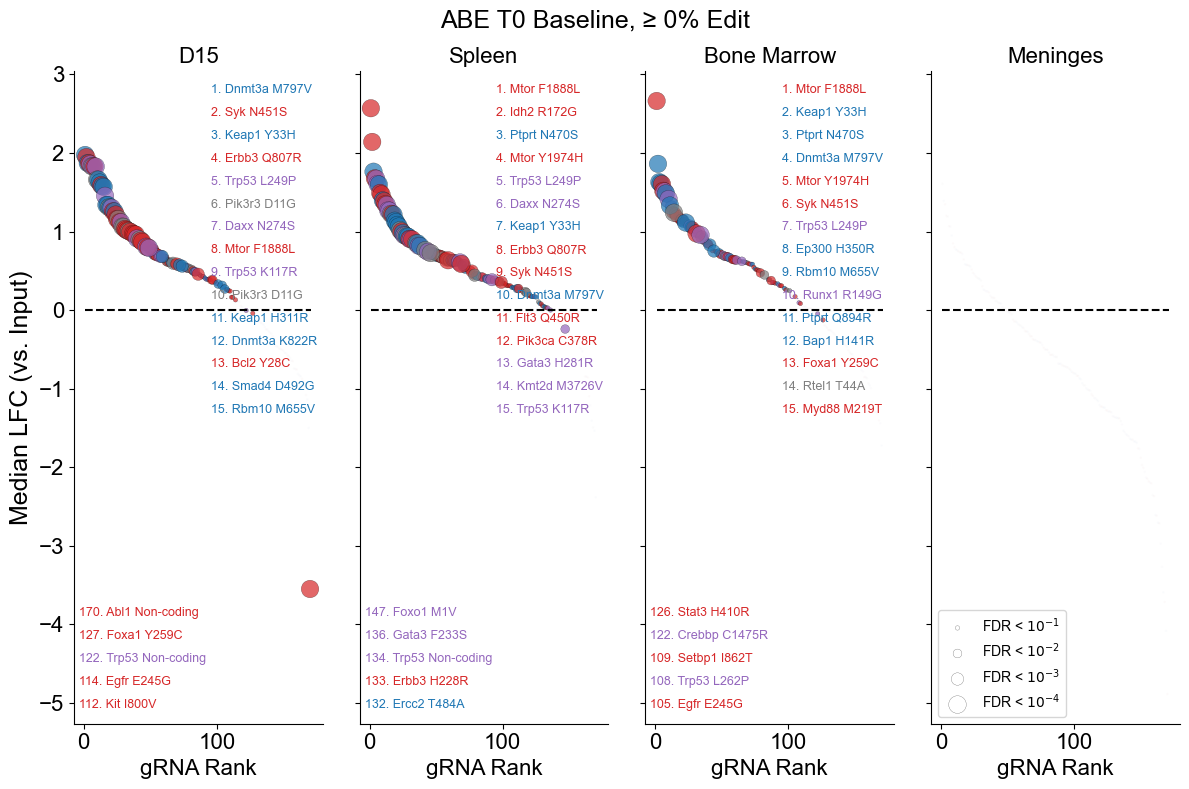

In [ ]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 100

ABE_targ = LFC_ABE[(LFC_ABE['classification']=='targeting guide')& (LFC_ABE['target_base_edit_perc']>=min_edit) & (LFC_ABE['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE T0 Baseline, ≥ 0% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_focused_t0_0.pdf', dpi=300)

In [61]:
cc2['classification'].value_counts()

classification
non-targeting control     186
targeting guide           170
safe-targeting control     17
Name: count, dtype: int64

In [62]:
greens  = sns.color_palette('Greens').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
blues = sns.color_palette('Blues').as_hex()
purples = sns.color_palette('Purples').as_hex()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


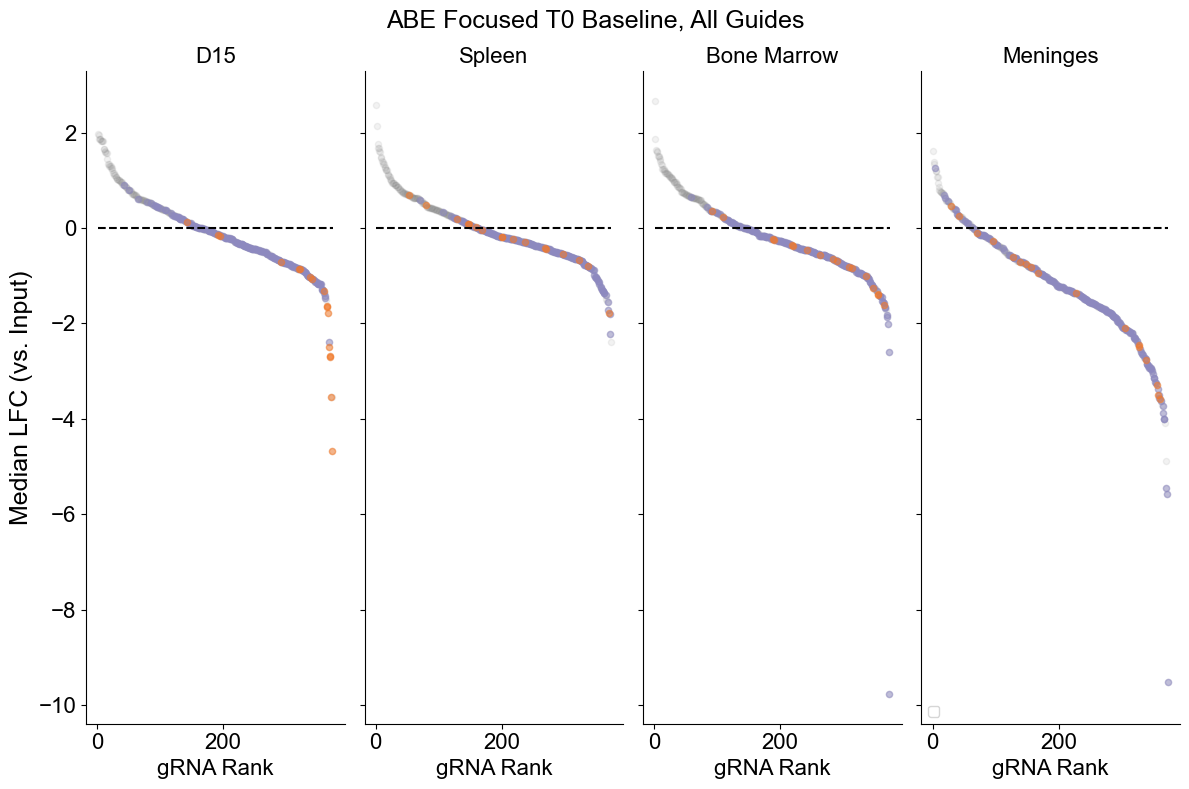

In [ ]:
min_edit = 0
min_input_counts = 100

ABE_targ = LFC_ABE[LFC_ABE['Input_median']>=min_input_counts]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = 'gray'
    ax[k].scatter(cc2['Rank'], cc2[f'LFC_median_{val}'], color='gray', s=20, alpha=.1)

    cc2_nt = cc2[cc2['classification'] == 'non-targeting control']
    cc2_st = cc2[cc2['classification'] == 'safe-targeting control']

    ax[k].scatter(cc2_nt['Rank'], cc2_nt[f'LFC_median_{val}'], color=purples[3], s=20, alpha=.5)
    ax[k].scatter(cc2_st['Rank'], cc2_st[f'LFC_median_{val}'], color=yellows[3], s=20, alpha=.5)

    if k==3:
        ax[k].legend(loc='lower left')

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

#ax.set_ylim(0,20)
plt.suptitle('ABE Focused T0 Baseline, All Guides',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_focused_t0_0.pdf', dpi=300)

d15
1 Dnmt3a M797V tab:blue
2 Syk N451S tab:red
3 Keap1 Y33H tab:blue
4 Erbb3 Q807R tab:red
5 Trp53 L249P tab:purple
6 Pik3r3 D11G tab:grey
7 Daxx N274S tab:purple
8 Trp53 K117R tab:purple
9 Pik3r3 D11G tab:grey
10 Keap1 H311R tab:blue
11 Dnmt3a K822R tab:blue
12 Bcl2 Y28C tab:red
13 Smad4 D492G tab:blue
14 Rbm10 M655V tab:blue
15 Trp53 H176R tab:purple
111 Kit I800V tab:red
113 Egfr E245G tab:red
121 Trp53 Non-coding tab:purple
126 Foxa1 Y259C tab:red
168 Abl1 Non-coding tab:red
spleen
1 Idh2 R172G tab:red
2 Ptprt N470S tab:blue
3 Mtor Y1974H tab:red
4 Trp53 L249P tab:purple
5 Daxx N274S tab:purple
6 Keap1 Y33H tab:blue
7 Erbb3 Q807R tab:red
8 Syk N451S tab:red
9 Dnmt3a M797V tab:blue
10 Flt3 Q450R tab:red
11 Pik3ca C378R tab:red
12 Gata3 H281R tab:purple
13 Kmt2d M3726V tab:purple
14 Trp53 K117R tab:purple
15 Rictor C1554R tab:grey
130 Ercc2 T484A tab:blue
131 Erbb3 H228R tab:red
132 Trp53 Non-coding tab:purple
134 Gata3 F233S tab:purple
145 Foxo1 M1V tab:purple
bm
1 Keap1 Y33H tab:b

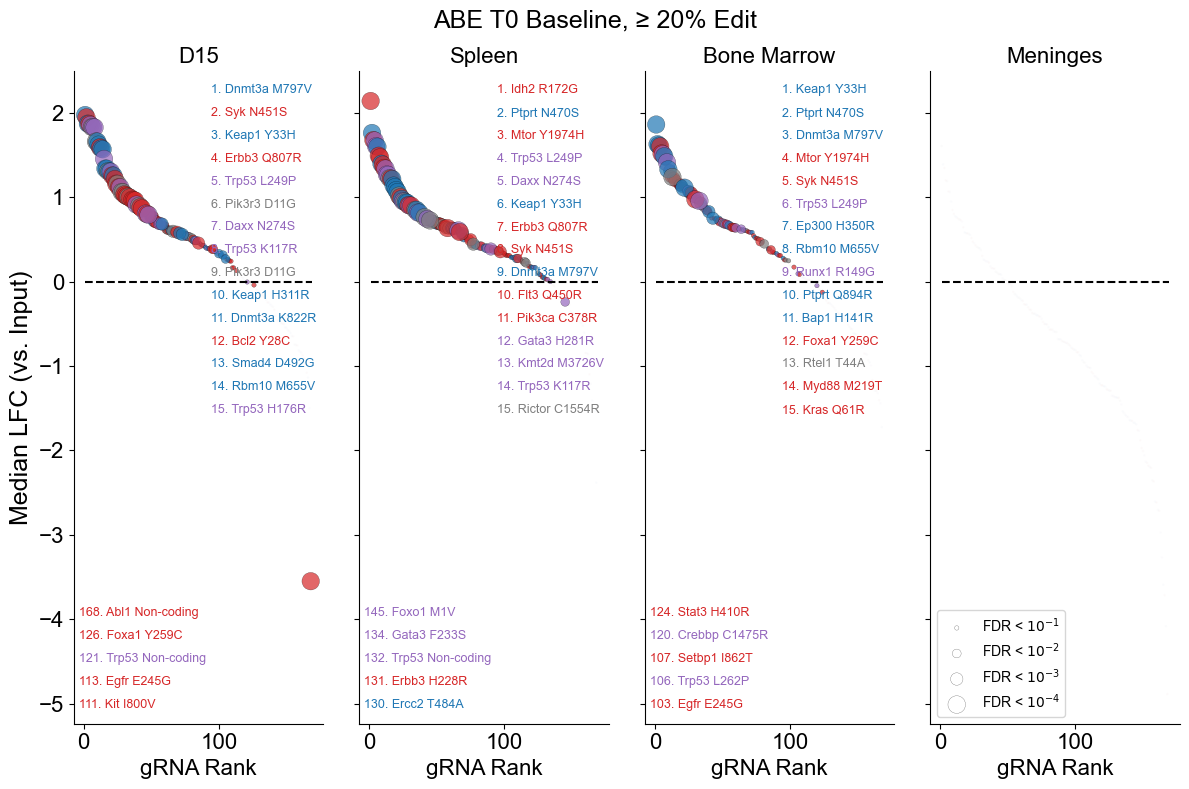

In [14]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 100

ABE_targ = LFC_ABE[(LFC_ABE['classification']=='targeting guide')& (LFC_ABE['target_base_edit_perc']>=min_edit) & (LFC_ABE['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE T0 Baseline, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_focused_t0_20.pdf', dpi=300)

d15
1 Pik3r3 D11G tab:grey
2 Daxx N274S tab:purple
3 Syk N451S tab:red
4 Raf1 R391G tab:red
5 Myc T73A tab:red
6 Ret K809E tab:red
7 Erbb3 Q807R tab:red
8 Keap1 Y33H tab:blue
9 Rbm10 H777R tab:blue
10 Arid5b K1026E tab:grey
11 Dnmt3a Non-coding tab:blue
12 Atrx N246S tab:blue
13 Kmt2d M3726V tab:purple
14 Flt3 R848G tab:red
15 Ep300 H350R tab:blue
135 Csf3r T774A tab:red
137 Pik3cg L44P tab:grey
139 Egfr E245G tab:red
142 Ptpn11 D61G tab:red
180 Abl1 Non-coding tab:red
spleen
1 Ctnnb1 S45P tab:red
2 Ercc2 T484A tab:blue
3 Nfe2 Q286R tab:grey
4 Ep300 H350R tab:blue
5 Syk N451S tab:red
6 Raf1 R391G tab:red
7 Gata3 H281R tab:purple
8 Smad4 K506E tab:blue
9 Smo I160V tab:red
10 Keap1 H311R tab:blue
11 Myd88 M219T tab:red
12 Egfr E245G tab:red
13 Ret K809E tab:red
14 Atm K2450E tab:blue
15 Smo I160V tab:red
100 Trp53 N236S tab:purple
103 Trp53 M243T tab:purple
105 Ercc2 Y14C tab:blue
106 Trp53 D278G tab:purple
109 Kit L579P tab:red
bonemarrow
1 Syk N451S tab:red
2 Ep300 H350R tab:blue
3 Ari

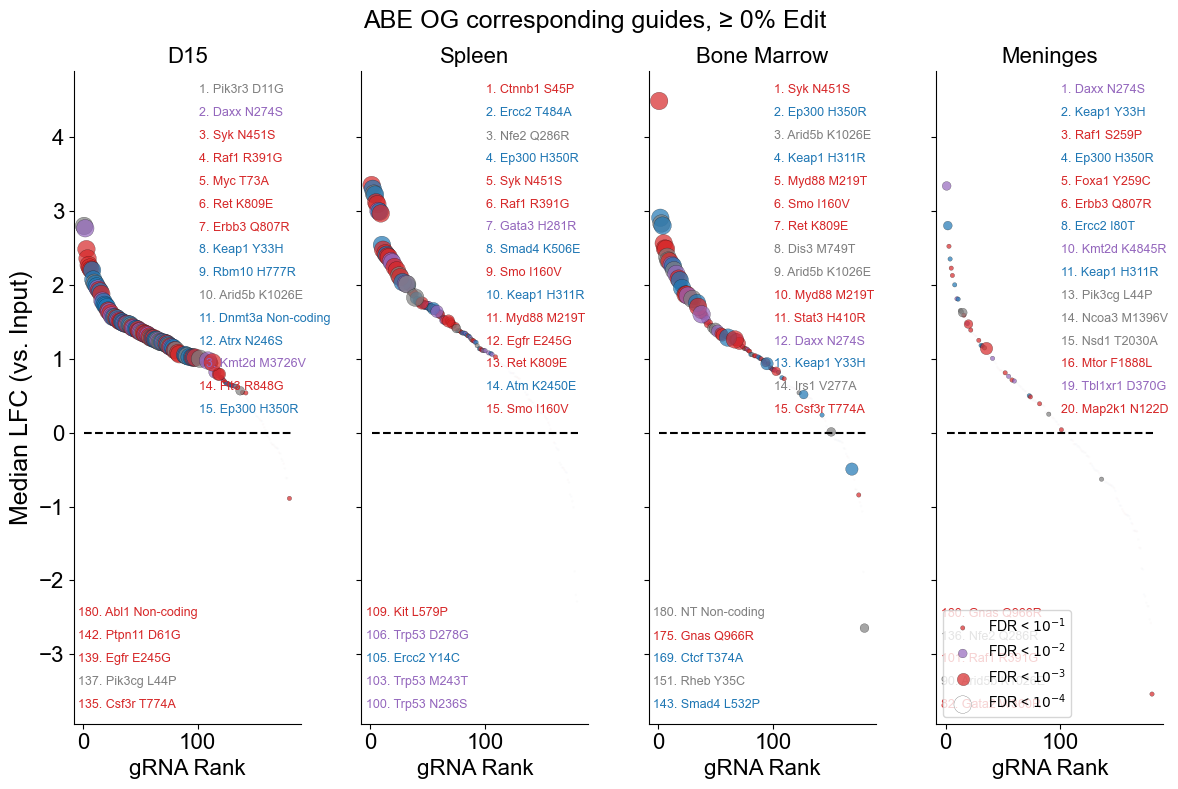

In [21]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 10

ABE_targ = LFC_ABE_OG[(LFC_ABE_OG['classification']=='targeting guide')& (LFC_ABE_OG['target_base_edit_perc']>=min_edit) & (LFC_ABE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
ABE_targ = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(LFC_ABE['gRNA_id'])].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE OG corresponding guides, ≥ 0% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_og_0.pdf', dpi=300)

d15
1 Pik3r3 D11G tab:grey
2 Daxx N274S tab:purple
3 Syk N451S tab:red
4 Raf1 R391G tab:red
5 Myc T73A tab:red
6 Ret K809E tab:red
7 Erbb3 Q807R tab:red
8 Keap1 Y33H tab:blue
9 Rbm10 H777R tab:blue
10 Arid5b K1026E tab:grey
11 Dnmt3a Non-coding tab:blue
12 Atrx N246S tab:blue
13 Kmt2d M3726V tab:purple
14 Flt3 R848G tab:red
15 Ep300 H350R tab:blue
135 Csf3r T774A tab:red
137 Pik3cg L44P tab:grey
139 Egfr E245G tab:red
142 Ptpn11 D61G tab:red
180 Abl1 Non-coding tab:red
spleen
1 Ctnnb1 S45P tab:red
2 Ercc2 T484A tab:blue
3 Nfe2 Q286R tab:grey
4 Ep300 H350R tab:blue
5 Syk N451S tab:red
6 Raf1 R391G tab:red
7 Gata3 H281R tab:purple
8 Smad4 K506E tab:blue
9 Smo I160V tab:red
10 Keap1 H311R tab:blue
11 Myd88 M219T tab:red
12 Egfr E245G tab:red
13 Ret K809E tab:red
14 Atm K2450E tab:blue
15 Smo I160V tab:red
100 Trp53 N236S tab:purple
103 Trp53 M243T tab:purple
105 Ercc2 Y14C tab:blue
106 Trp53 D278G tab:purple
109 Kit L579P tab:red
bonemarrow
1 Syk N451S tab:red
2 Ep300 H350R tab:blue
3 Ari

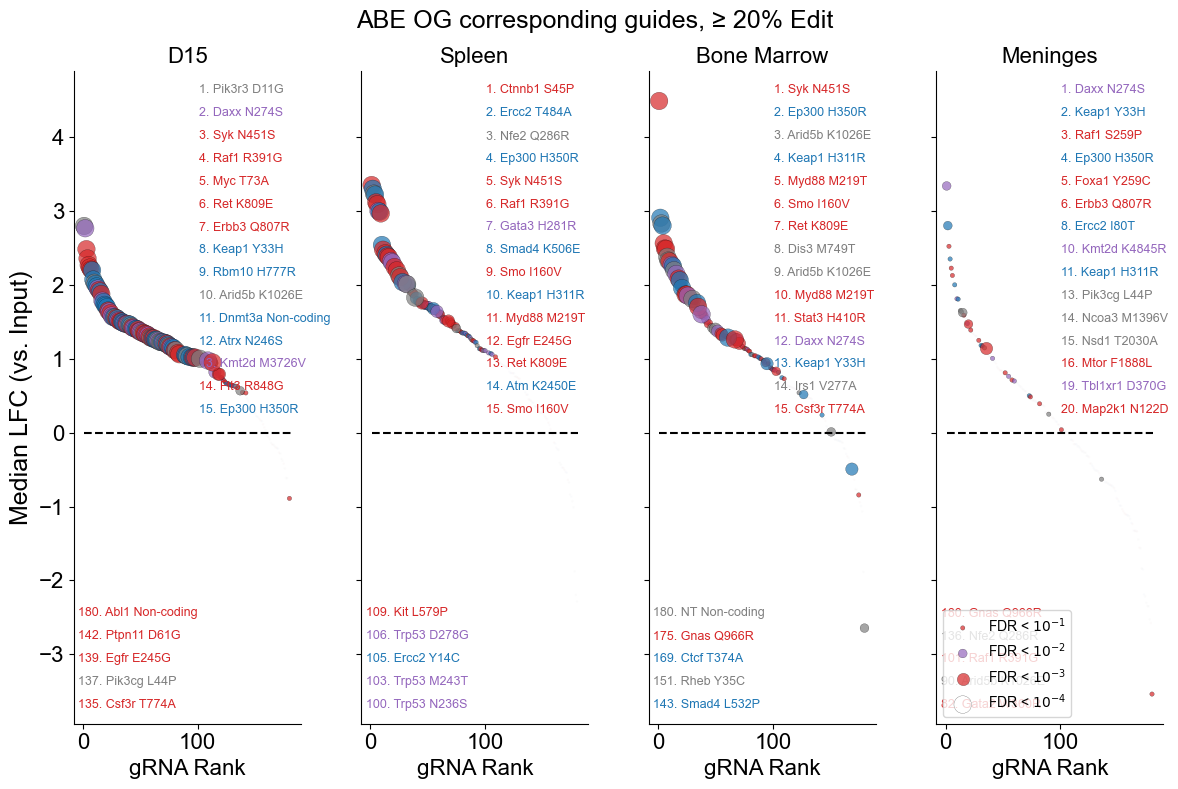

In [22]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 10

ABE_targ = LFC_ABE_OG[(LFC_ABE_OG['classification']=='targeting guide')& (LFC_ABE_OG['target_base_edit_perc']>=min_edit) & (LFC_ABE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
ABE_targ = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(LFC_ABE['gRNA_id'])].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE OG corresponding guides, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_og_20.pdf', dpi=300)

d15
1 Mtor F1888L tab:red
2 Trp53 K117R tab:purple
3 Dnmt3a M797V tab:blue
4 Keap1 Y33H tab:blue
5 Keap1 H311R tab:blue
6 Gata3 H281R tab:purple
7 Pik3r3 D11G tab:grey
8 Erbb3 Q807R tab:red
9 Trp53 L249P tab:purple
10 Trp53 M243T tab:purple
11 Dnmt3a K822R tab:blue
12 Erbb3 H228R tab:red
13 Syk N451S tab:red
14 Arid5b K1026E tab:grey
15 Smad4 D492G tab:blue
129 Ep300 H350R tab:blue
131 Egfr E245G tab:red
134 Lck T497A tab:red
137 Trp53 Non-coding tab:purple
170 Gnas Q966R tab:red
spleen
1 Mtor F1888L tab:red
2 Mtor Y1974H tab:red
3 Dnmt3a M797V tab:blue
4 Ret K809E tab:red
5 Idh2 R172G tab:red
6 Kmt2d M3726V tab:purple
7 Ptprt N470S tab:blue
8 Daxx N274S tab:purple
9 Dnmt3a Non-coding tab:blue
10 Rbm10 M655V tab:blue
11 Ep300 Q2287R tab:blue
12 Keap1 Y33H tab:blue
13 Kmt2d K4845R tab:purple
14 Trp53 K117R tab:purple
15 Smo I160V tab:red
100 Kit L579P tab:red
104 Fgf4 R108G tab:grey
122 Foxo1 M1V tab:purple
169 Phf6 H302R tab:blue
170 Smad4 K506E tab:blue
bm
1 Lck T497A tab:red
2 Arid5b

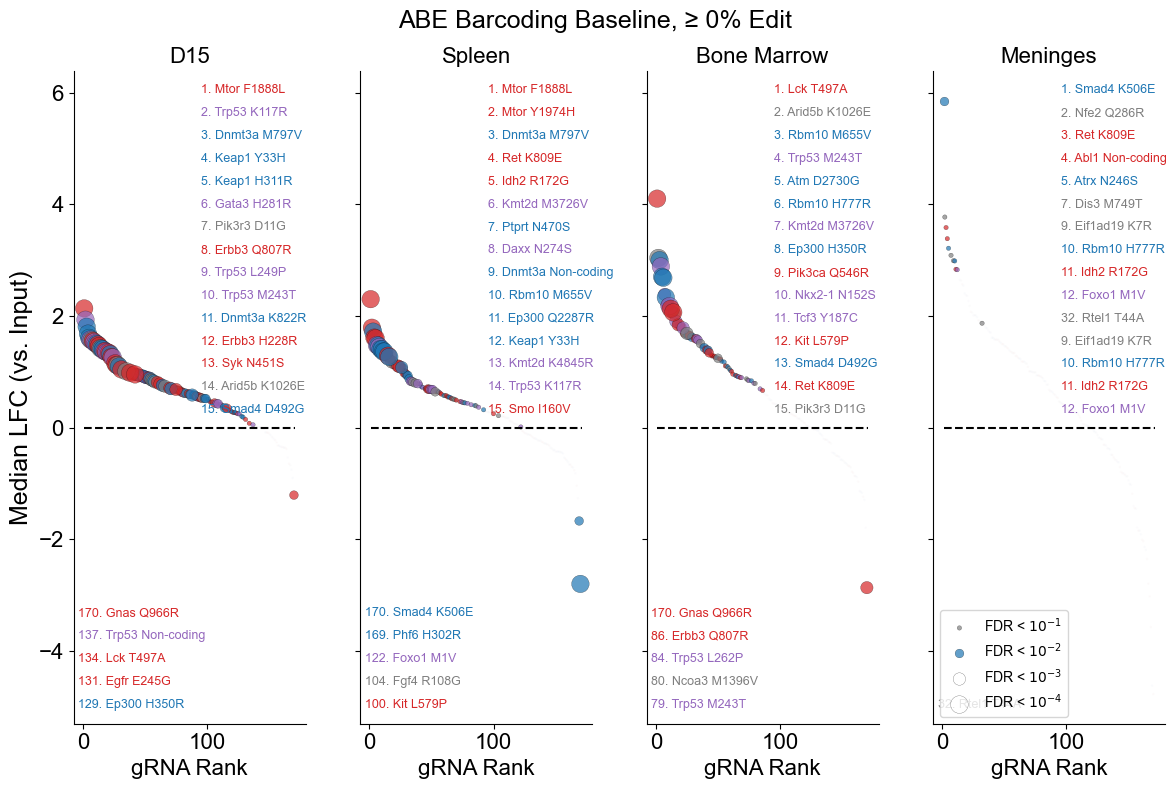

In [30]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 100

ABE_targ = LFC_ABE_VS_BC[(LFC_ABE_VS_BC['classification']=='targeting guide')&  (LFC_ABE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_ABE_VS_BC['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE Barcoding Baseline, ≥ 0% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_focused_bc_0.pdf', dpi=300)

d15
1 Trp53 K117R tab:purple
2 Dnmt3a M797V tab:blue
3 Keap1 Y33H tab:blue
4 Keap1 H311R tab:blue
5 Gata3 H281R tab:purple
6 Pik3r3 D11G tab:grey
7 Erbb3 Q807R tab:red
8 Trp53 L249P tab:purple
9 Trp53 M243T tab:purple
10 Dnmt3a K822R tab:blue
11 Erbb3 H228R tab:red
12 Syk N451S tab:red
13 Arid5b K1026E tab:grey
14 Smad4 D492G tab:blue
15 Ptprt Q894R tab:blue
127 Ep300 H350R tab:blue
129 Egfr E245G tab:red
132 Lck T497A tab:red
135 Trp53 Non-coding tab:purple
168 Gnas Q966R tab:red
spleen
1 Mtor Y1974H tab:red
2 Dnmt3a M797V tab:blue
3 Ret K809E tab:red
4 Idh2 R172G tab:red
5 Kmt2d M3726V tab:purple
6 Ptprt N470S tab:blue
7 Daxx N274S tab:purple
8 Dnmt3a Non-coding tab:blue
9 Rbm10 M655V tab:blue
10 Ep300 Q2287R tab:blue
11 Keap1 Y33H tab:blue
12 Kmt2d K4845R tab:purple
13 Trp53 K117R tab:purple
14 Smo I160V tab:red
15 Dnmt3a Non-coding tab:blue
99 Kit L579P tab:red
103 Fgf4 R108G tab:grey
121 Foxo1 M1V tab:purple
167 Phf6 H302R tab:blue
168 Smad4 K506E tab:blue
bm
1 Lck T497A tab:red
2

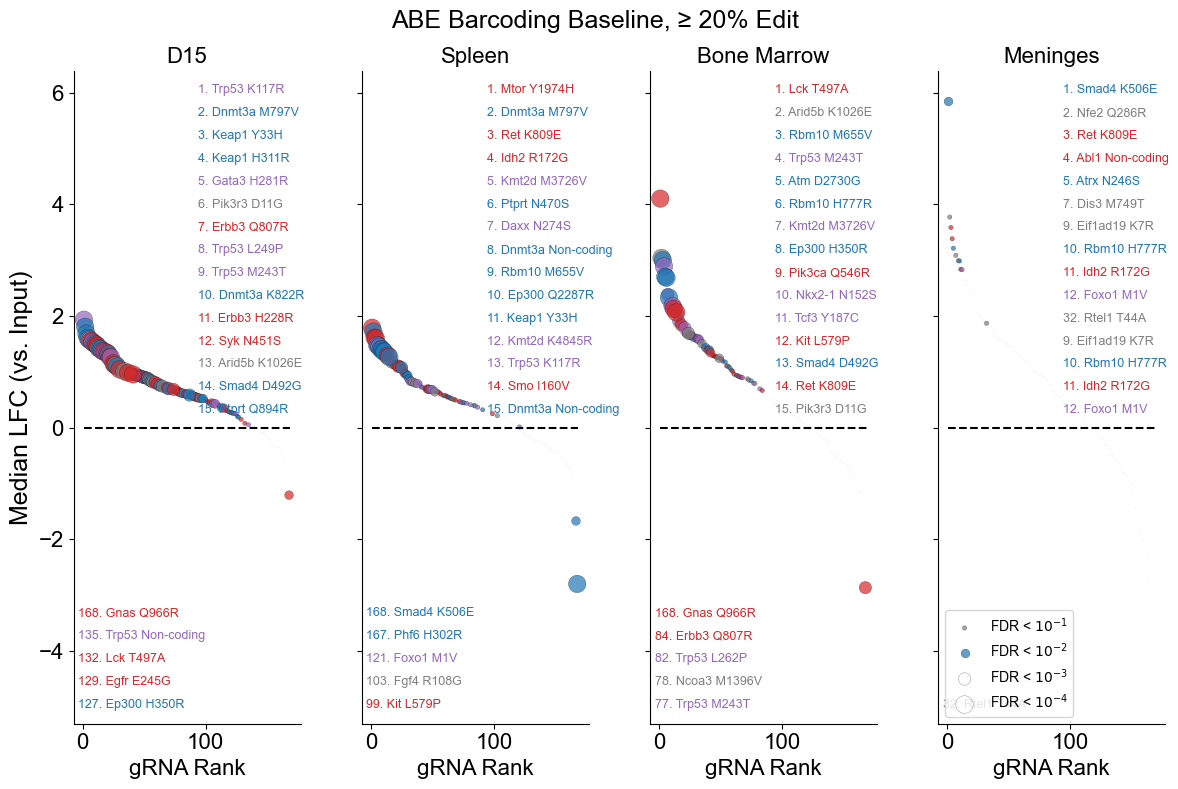

In [31]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 100

ABE_targ = LFC_ABE_VS_BC[(LFC_ABE_VS_BC['classification']=='targeting guide')& (LFC_ABE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_ABE_VS_BC['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
    top = cc3[:15]
    bottom = cc3[-5:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')


    top_n = 15
    bottom_n = len(ns) - top_n  # should be 5

    x_left = 0.02
    x_right = 0.55
    y_top_start = 0.98
    line_h = 0.035  # adjust spacing if needed

    # Ensure there are enough elements in the lists before accessing them
    if len(ns) >= top_n:
        # Top list (first 15)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,  # right column
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

    if len(ns) > top_n:
        # Bottom list (last 5) -- NOTE the color index offset must be +top_n
        for j in range(bottom_n):
            idx = top_n + j
            if idx < len(ns):  # Ensure idx is within bounds
                ax[k].text(
                    x_left, 0.02 + j * line_h,          # left-bottom column
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],                      
                    clip_on=False
                )

    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('ABE Barcoding Baseline, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_abe_focused_bc_20.pdf', dpi=300)

## Three genes

d15
1 Trp53 L249P tab:purple
2 Trp53 K117R tab:purple
3 Trp53 H176R tab:purple
4 Trp53 N236S tab:purple
5 Trp53 I248T tab:purple
6 Trp53 M243T tab:purple
7 Trp53 M243T tab:purple
8 Trp53 I192T tab:purple
9 Trp53 R277G tab:purple
10 Trp53 Non-coding tab:purple
6 Trp53 M243T tab:purple
7 Trp53 M243T tab:purple
8 Trp53 I192T tab:purple
9 Trp53 R277G tab:purple
10 Trp53 Non-coding tab:purple
spleen
1 Trp53 L249P tab:purple
2 Trp53 K117R tab:purple
3 Trp53 M243T tab:purple
4 Trp53 R277G tab:purple
5 Trp53 I248T tab:purple
6 Trp53 N236S tab:purple
7 Trp53 H176R tab:purple
8 Trp53 I192T tab:purple
9 Trp53 L262P tab:purple
10 Trp53 M243T tab:purple
11 Trp53 Non-coding tab:purple
7 Trp53 H176R tab:purple
8 Trp53 I192T tab:purple
9 Trp53 L262P tab:purple
10 Trp53 M243T tab:purple
11 Trp53 Non-coding tab:purple
bm
1 Trp53 L249P tab:purple
2 Trp53 H176R tab:purple
3 Trp53 I248T tab:purple
4 Trp53 K117R tab:purple
5 Trp53 M243T tab:purple
6 Trp53 R277G tab:purple
7 Trp53 Non-coding tab:purple
8 Trp

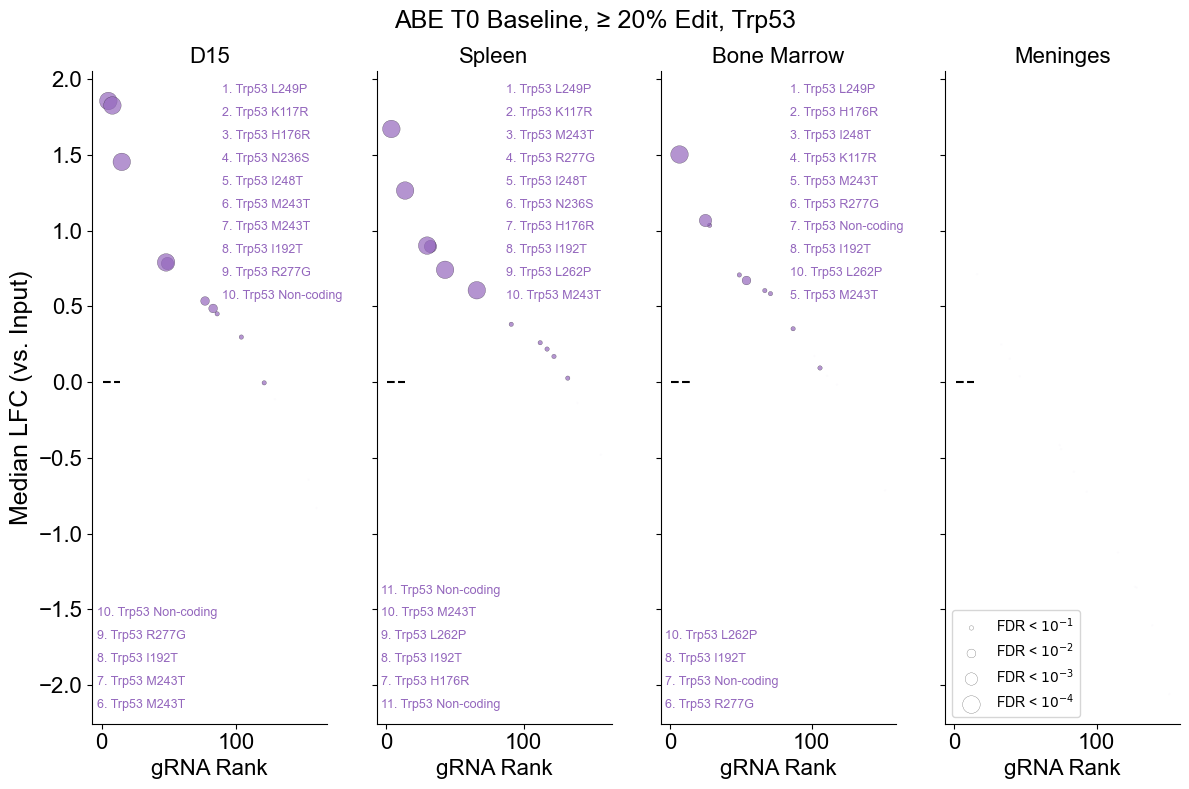

d15
spleen
1 Ctnnb1 S45P tab:red
1 Ctnnb1 S45P tab:red
bm
men


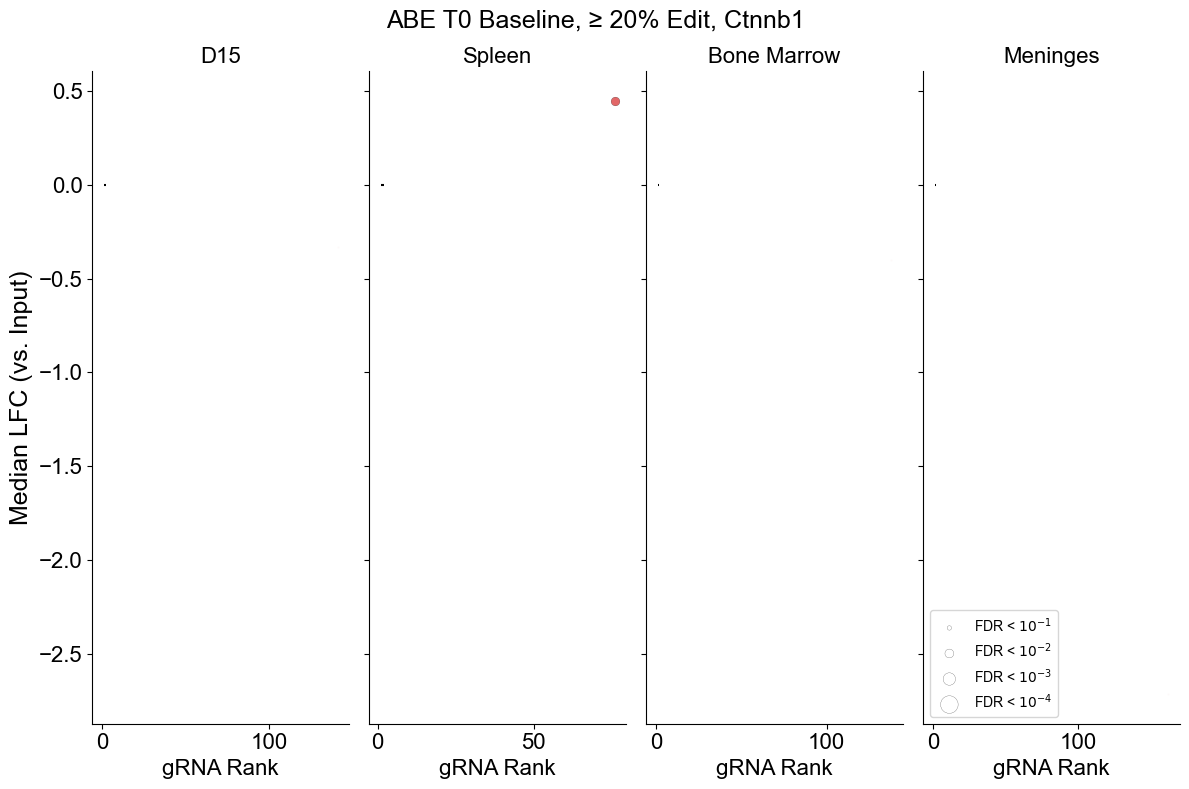

d15
spleen
bm
men


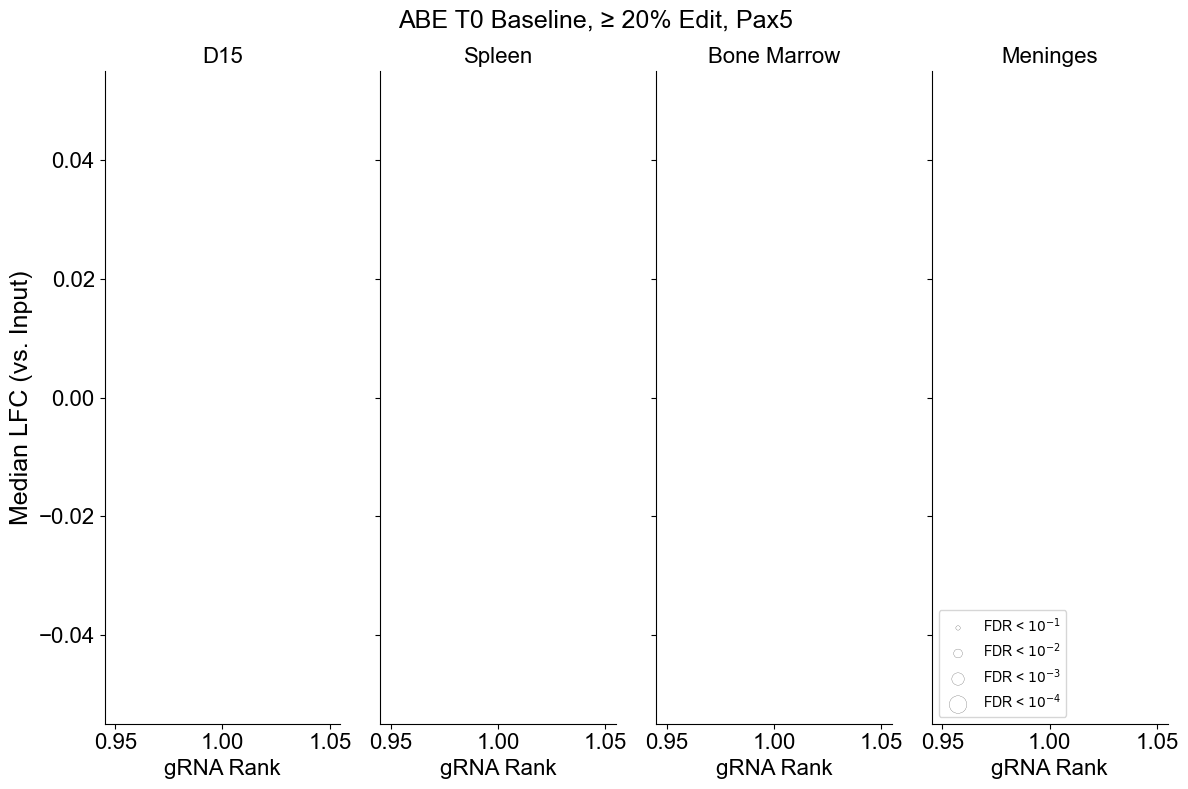

In [38]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:
    min_edit = 20
    FDR_cutoff = .1
    min_input_counts = 100

    ABE_targ = LFC_ABE[(LFC_ABE['classification']=='targeting guide')& (LFC_ABE['target_base_edit_perc']>=min_edit) & (LFC_ABE['Input_median']>=min_input_counts)]

    #-----and plotting--------
    names2 = ['d15','spleen', 'bm', 'men',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)
        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

        #and annotate top and bottom 5 variant
        cc3 = cc2[cc2[f'FDR_{val}_fishers']<FDR_cutoff]
        top = cc3[:15]
        bottom = cc3[-5:]
        tb = pd.concat((top, bottom))

        t = []
        x = []
        y = []
        c = []

        ns = []
        print(val)
        for i, val2 in tb.iterrows():
            y.append(val2[f'LFC_median_{val}'])
            x.append(val2['Rank'])
            c.append(val2['color'])
            a = val2['HGVSp_m']
            if a=='Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            t.append(f'{b} {a}')

            ns.append(f'{val2["Rank_gene"]}. {b} {a}')
            print(f'{val2["Rank_gene"]} {b} {a} {val2["color"]}')


        top_n = 10
        bottom_n = len(ns) - top_n  # should be 5

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035  # adjust spacing if needed

        # Ensure there are enough elements in the lists before accessing them
        if len(ns) >= top_n:
            # Top list (first 15)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,  # right column
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

        if len(ns) > top_n:
            # Bottom list (last 5) -- NOTE the color index offset must be +top_n
            for j in range(bottom_n):
                idx = top_n + j
                if idx < len(ns):  # Ensure idx is within bounds
                    ax[k].text(
                        x_left, 0.02 + j * line_h,          # left-bottom column
                        ns[idx],
                        transform=ax[k].transAxes,
                        ha='left', va='bottom',
                        fontsize=9,
                        color=c[idx],                      
                        clip_on=False
                    )

    #ax.set_ylim(0,20)
    plt.suptitle(f'ABE T0 Baseline, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_abe_focused_t0_20_{gene_of_interest}.pdf', dpi=300)
    plt.show()

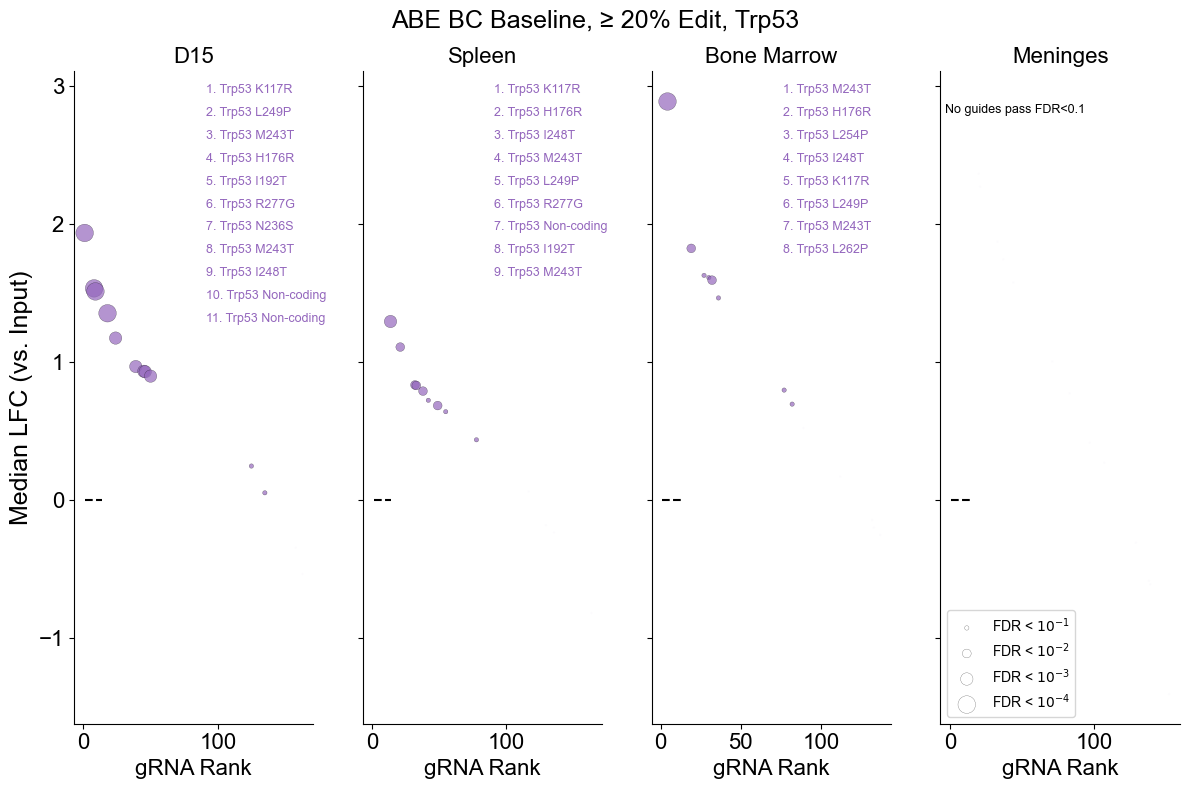

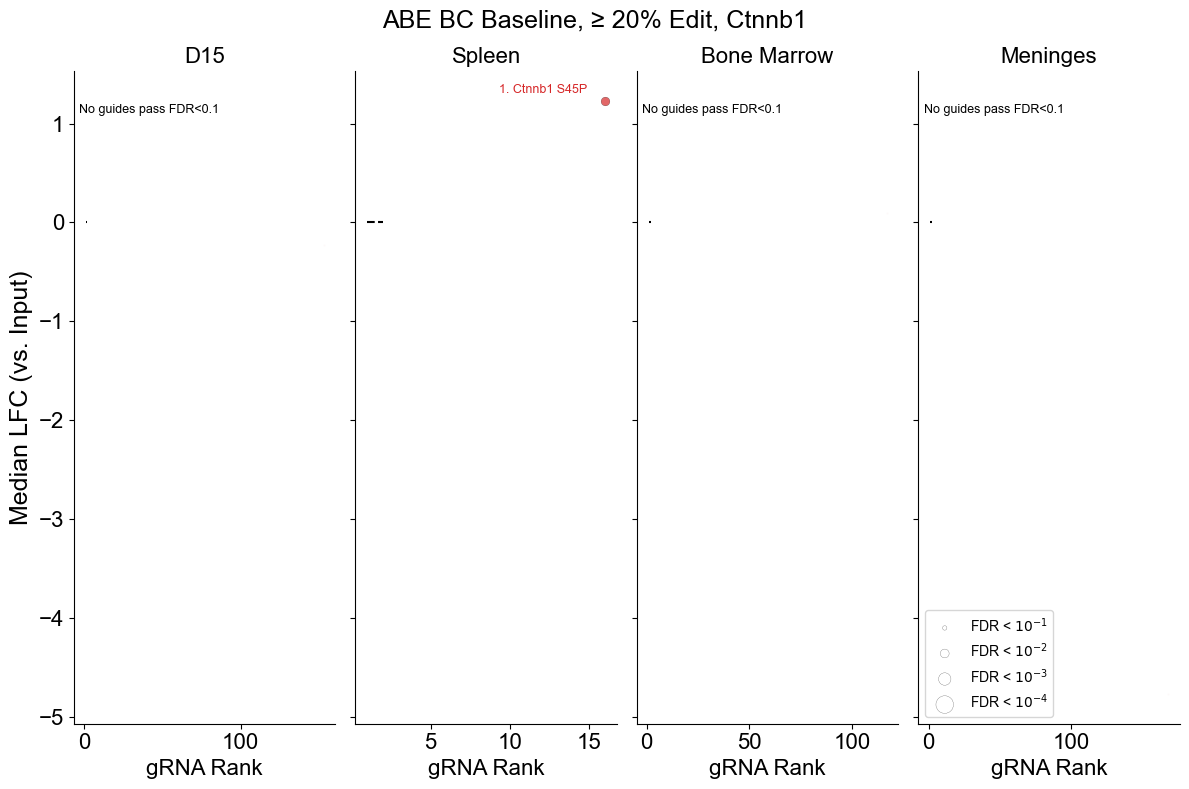

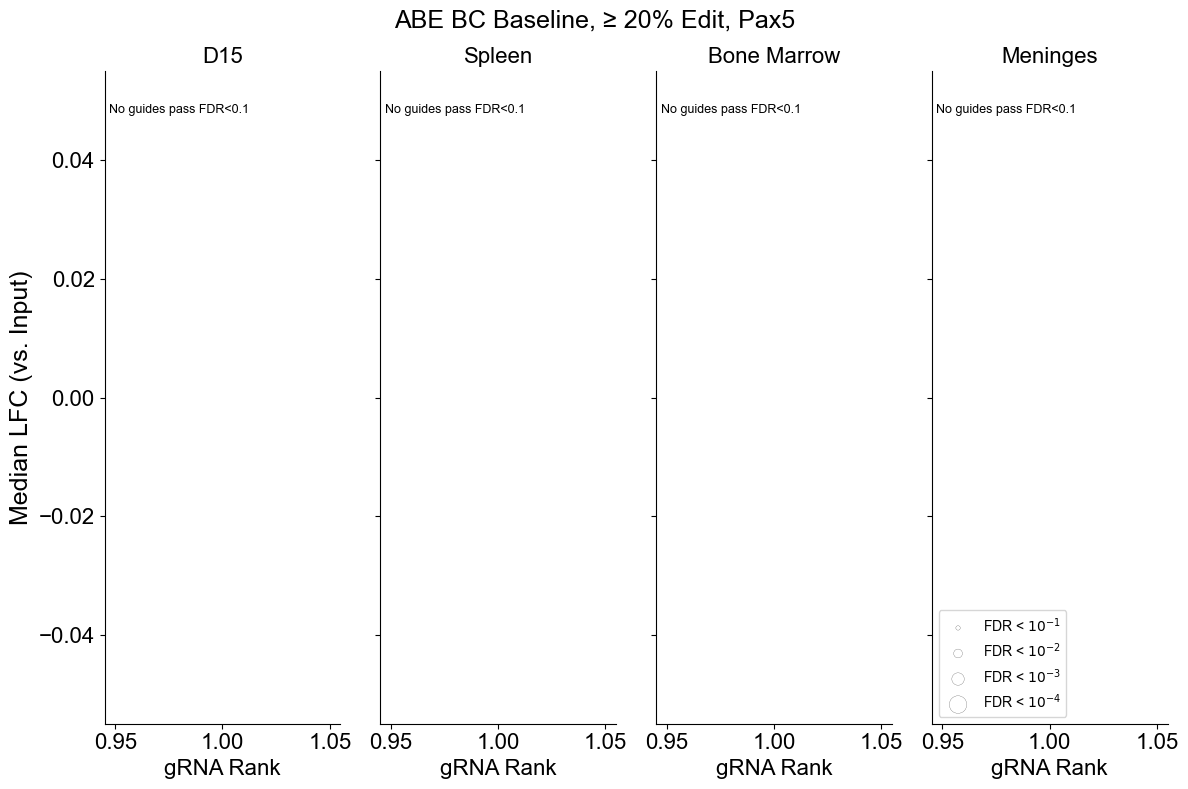

In [44]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:
    min_edit = 20
    FDR_cutoff = .1
    min_input_counts = 100

    ABE_targ = LFC_ABE_VS_BC[(LFC_ABE_VS_BC['classification']=='targeting guide')&  (LFC_ABE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_ABE_VS_BC['Input_median']>=min_input_counts)]

    #-----and plotting--------
    names2 = ['d15','spleen', 'bm', 'men',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)

        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

        cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()

        # If nothing significant, optionally show a small note and skip
        if len(cc3) == 0:
            ax[k].text(
                0.02, 0.95, "No guides pass FDR<0.1",
                transform=ax[k].transAxes,
                ha="left", va="top",
                fontsize=9, color="black"
            )
        else:
            top_n = min(15, len(cc3))
            bottom_n = min(5, max(0, len(cc3) - top_n))

            top = cc3.iloc[:top_n]
            bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

            tb = pd.concat((top, bottom))

            ns = []
            c = []
            for _, val2 in tb.iterrows():
                a = val2['HGVSp_m']
                if a == 'Not calculated (legacy)':
                    a = val2['HGVSp_h'] + ' (human)'
                b = val2['gene_name_m_corrected']
                ns.append(f'{val2["Rank_gene"]}. {b} {a}')
                c.append(val2['color'])

            x_left = 0.02
            x_right = 0.55
            y_top_start = 0.98
            line_h = 0.035

            # Draw top list (whatever is available)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

            # Draw bottom list (if any)
            for j in range(bottom_n):
                idx = top_n + j
                ax[k].text(
                    x_left, 0.02 + j * line_h,
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],
                    clip_on=False
                )

    #ax.set_ylim(0,20)
    plt.suptitle(f'ABE BC Baseline, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_abe_focused_bc_20_{gene_of_interest}.pdf', dpi=300)
    plt.show()

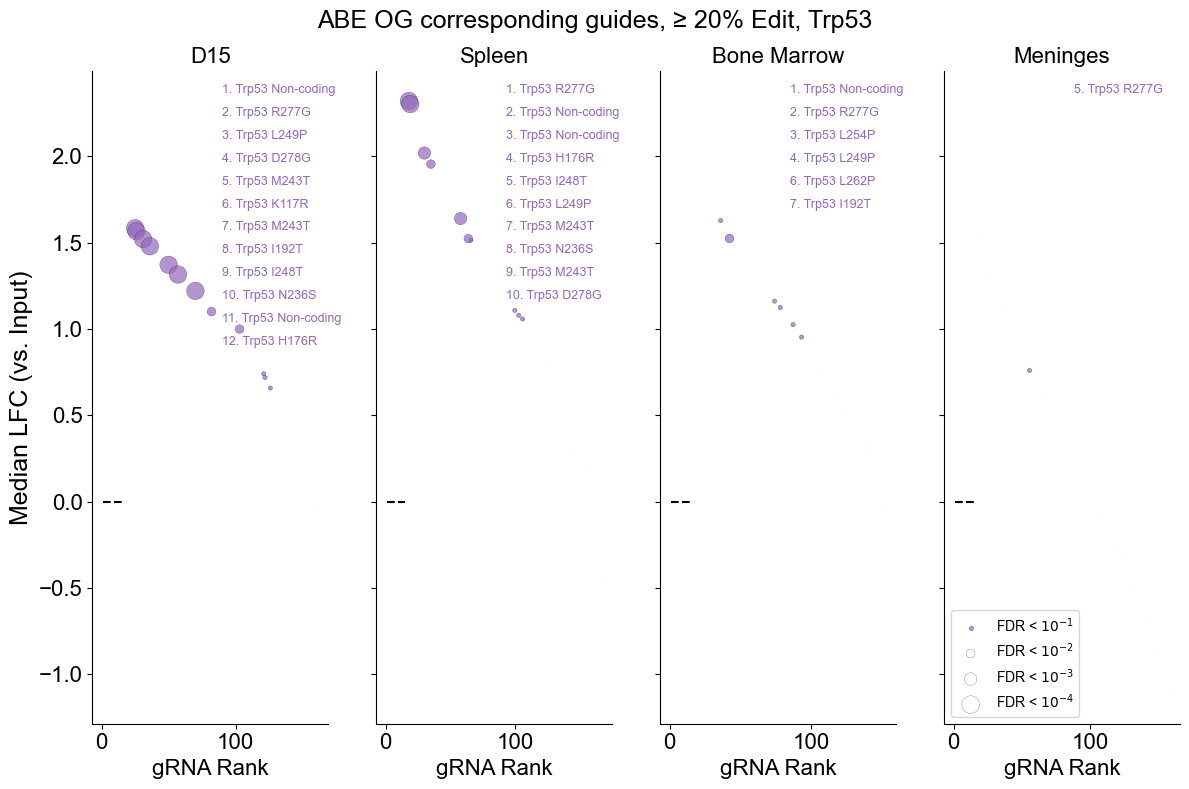

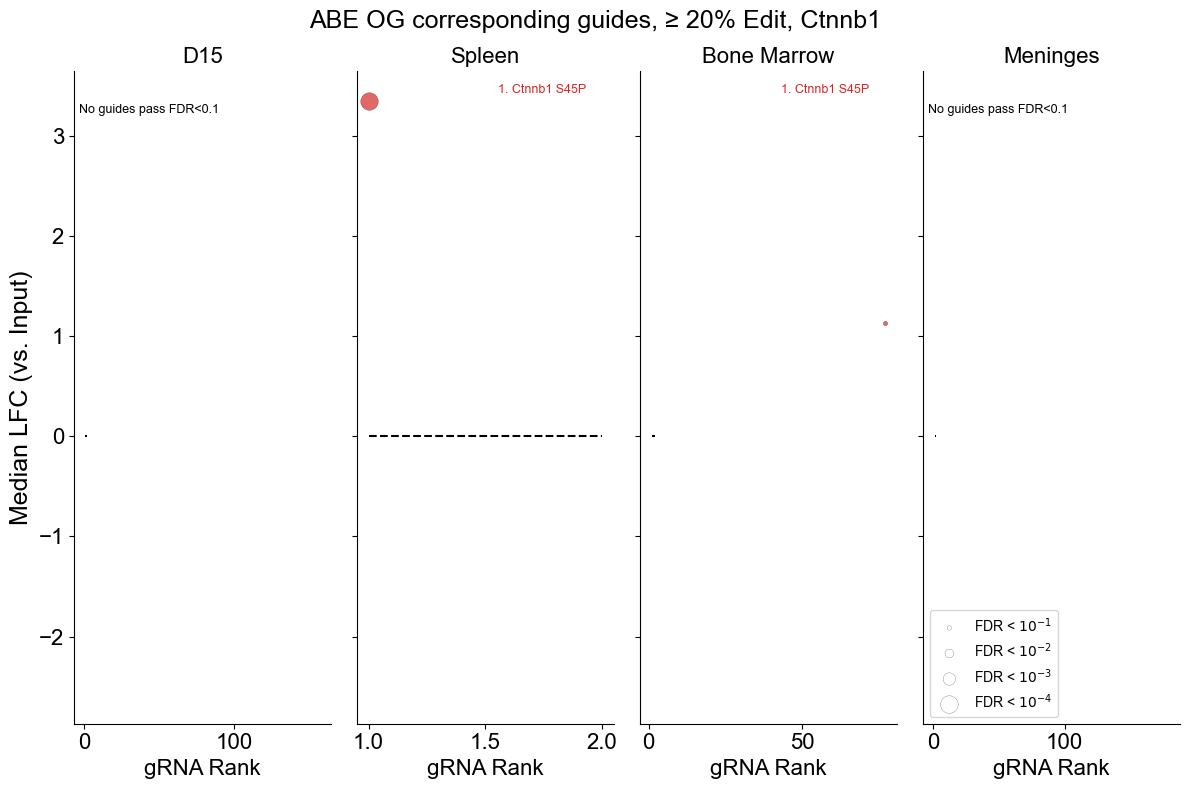

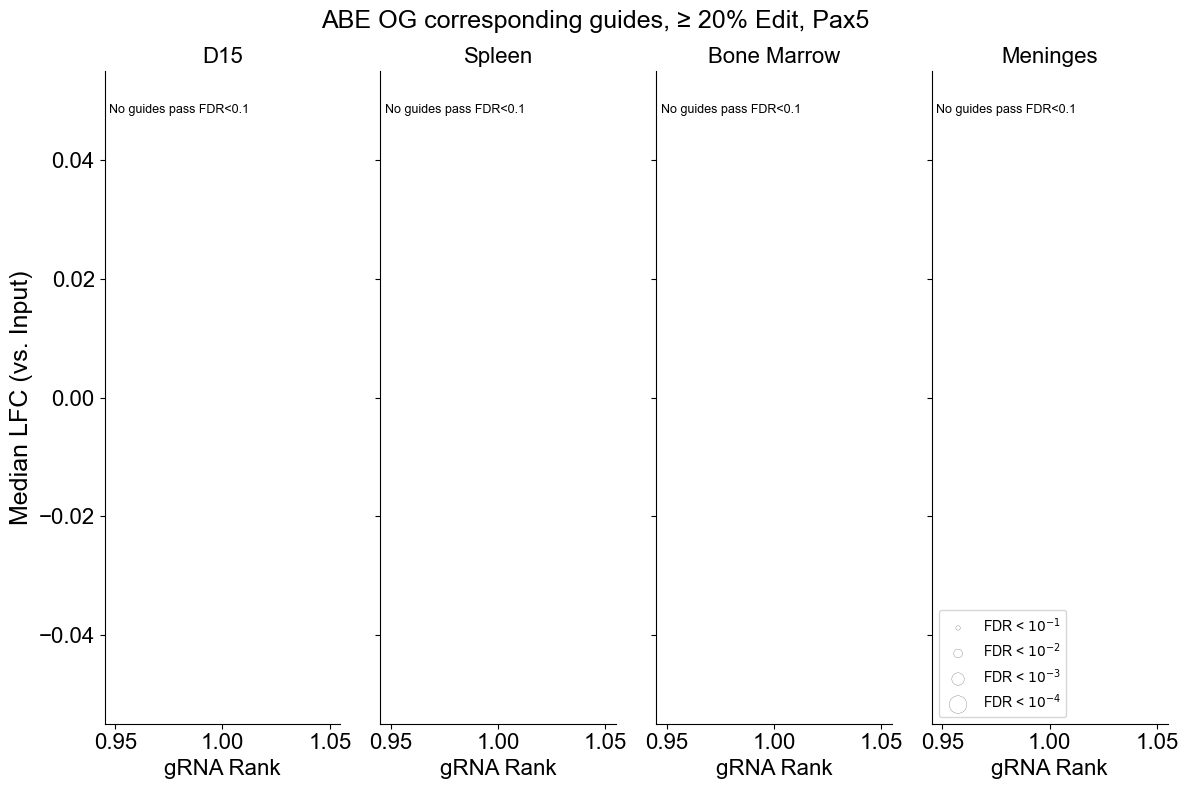

In [43]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:
    min_edit = 20
    FDR_cutoff = .1
    min_input_counts = 100

    ABE_targ = LFC_ABE_OG[(LFC_ABE_OG['classification']=='targeting guide')& (LFC_ABE_OG['target_base_edit_perc']>=min_edit) & (LFC_ABE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
    ABE_targ = LFC_ABE_OG[LFC_ABE_OG['gRNA_id'].isin(LFC_ABE['gRNA_id'])].reset_index(drop=True)

    #-----and plotting--------
    names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = ABE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)

        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

        cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
        if len(cc3) == 0:
            ax[k].text(
                0.02, 0.95, "No guides pass FDR<0.1",
                transform=ax[k].transAxes,
                ha="left", va="top",
                fontsize=9, color="black"
            )
        else:
            top_n = min(15, len(cc3))
            bottom_n = min(5, max(0, len(cc3) - top_n))

            top = cc3.iloc[:top_n]
            bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

            tb = pd.concat((top, bottom))

            ns = []
            c = []
            for _, val2 in tb.iterrows():
                a = val2['HGVSp_m']
                if a == 'Not calculated (legacy)':
                    a = val2['HGVSp_h'] + ' (human)'
                b = val2['gene_name_m_corrected']
                ns.append(f'{val2["Rank_gene"]}. {b} {a}')
                c.append(val2['color'])

            x_left = 0.02
            x_right = 0.55
            y_top_start = 0.98
            line_h = 0.035

            # Draw top list (whatever is available)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

            # Draw bottom list (if any)
            for j in range(bottom_n):
                idx = top_n + j
                ax[k].text(
                    x_left, 0.02 + j * line_h,
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],
                    clip_on=False
                )

    #ax.set_ylim(0,20)
    plt.suptitle(f'ABE OG corresponding guides, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_abe_og_20_{gene_of_interest}.pdf', dpi=300)
    plt.show()

# CBE

In [ ]:
list_NGG_PAM = [f'{x}GG' for x in ['A','T','G','C']]
guides_NGG_CBE_focused = list(LIB[ (LIB['Editor']=='CBE') & (LIB['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])
guides_NGG_CBE_og = list(LIB_OG[ (LIB_OG['Editor']=='CBE') & (LIB_OG['PAM_NGN'].isin(list_NGG_PAM)) ]['gRNA_id'])

In [67]:
LFC_CBE['classification'].unique()

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


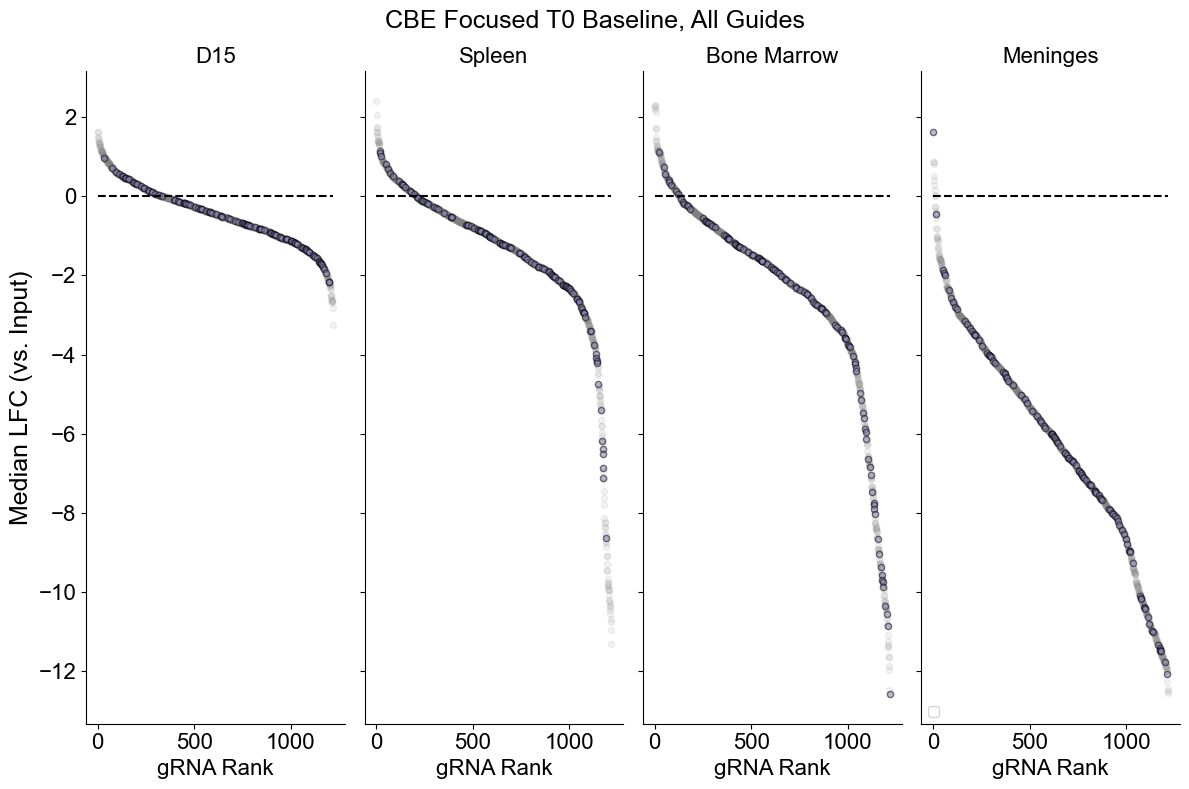

In [69]:
min_edit = 0
min_input_counts = 100

CBE_targ = LFC_CBE[LFC_CBE['Input_median']>=min_input_counts]

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = 'gray'
    ax[k].scatter(cc2['Rank'], cc2[f'LFC_median_{val}'], color='gray', s=20, alpha=.1)

    cc2_nt = cc2[cc2['classification'] == 'essential truncation guide']
    #cc2_st = cc2[cc2['classification'] == 'safe-targeting control']

    ax[k].scatter(cc2_nt['Rank'], cc2_nt[f'LFC_median_{val}'], color=purples[3], s=20, edgecolor = 'black',alpha=.5)
    #ax[k].scatter(cc2_st['Rank'], cc2_st[f'LFC_median_{val}'], color=yellows[3], s=20, alpha=.5)

    if k==3:
        ax[k].legend(loc='lower left')

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

#ax.set_ylim(0,20)
plt.suptitle('CBE Focused T0 Baseline, All Guides',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
# plt.savefig('figures/waterfall_abe_focused_t0_0.pdf', dpi=300)

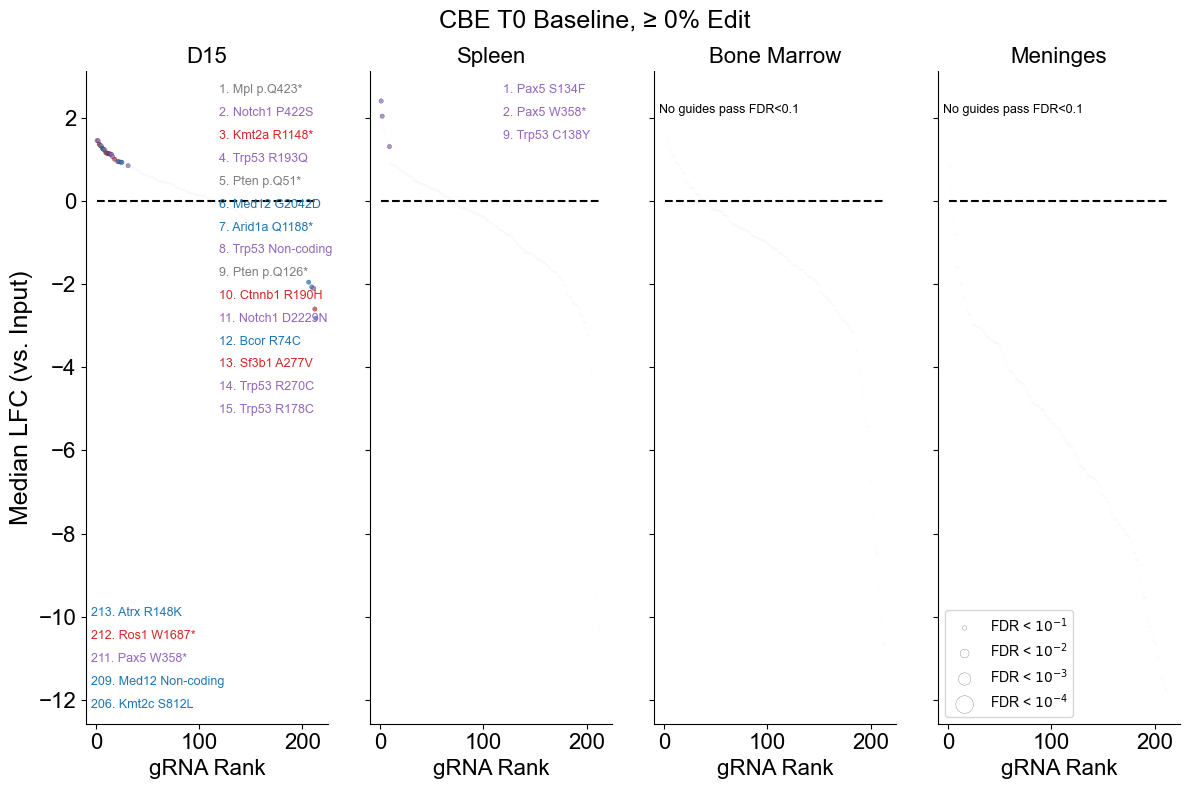

In [12]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 100

CBE_targ = LFC_CBE[(LFC_CBE['classification']=='targeting guide')& (LFC_CBE['target_base_edit_perc']>=min_edit) & (LFC_CBE['Input_median']>=min_input_counts)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

  
    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )
    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)
plt.suptitle('CBE T0 Baseline, ≥ 0% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_focused_t0_0.pdf', dpi=300)

In [30]:
LFC_CBE['classification'].unique(
)

array(['targeting guide', 'non-targeting control',
       'essential truncation guide', 'safe-targeting control'],
      dtype=object)

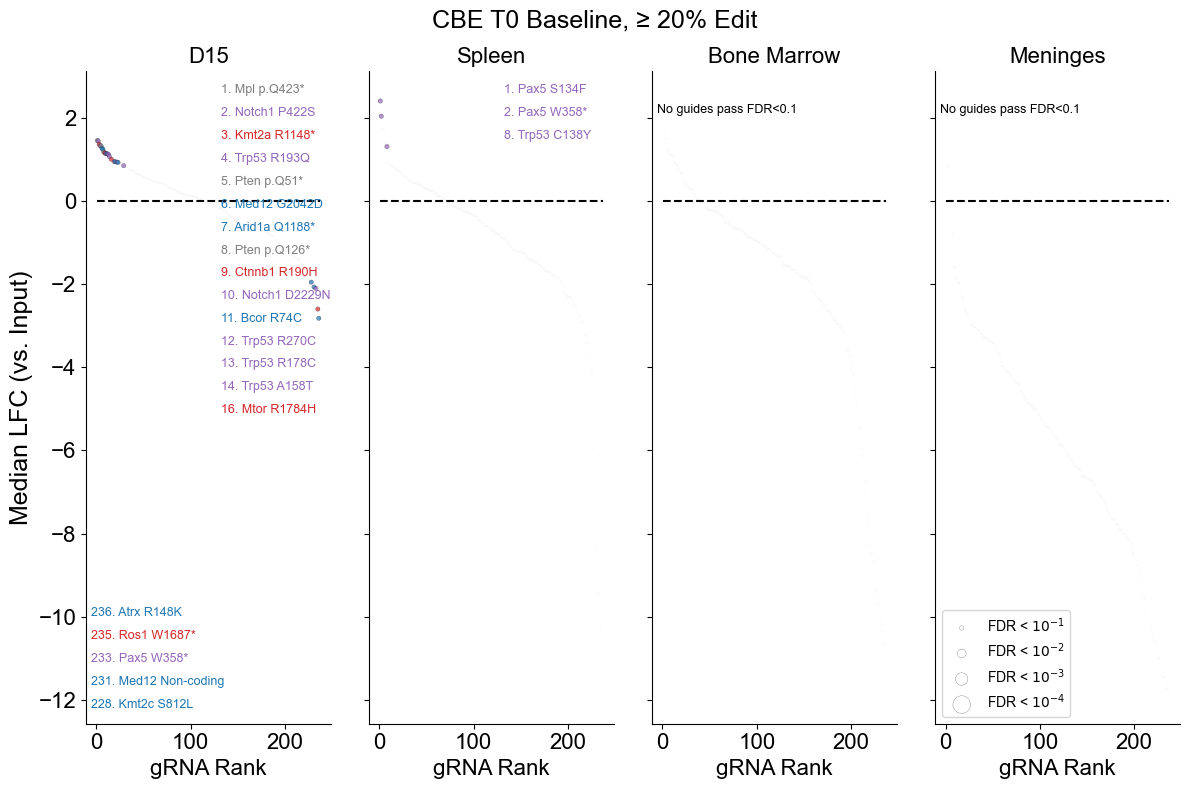

In [31]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 100

CBE_targ = LFC_CBE[(LFC_CBE['classification'].isin(['targeting guide', 'essential truncation guide']) & 
                    (LFC_CBE['target_base_edit_perc'] >= min_edit) & 
                    (LFC_CBE['Input_median'] >= min_input_counts))].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )

#ax.set_ylim(0,20)
plt.suptitle('CBE T0 Baseline, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_focused_t0_20.pdf', dpi=300)

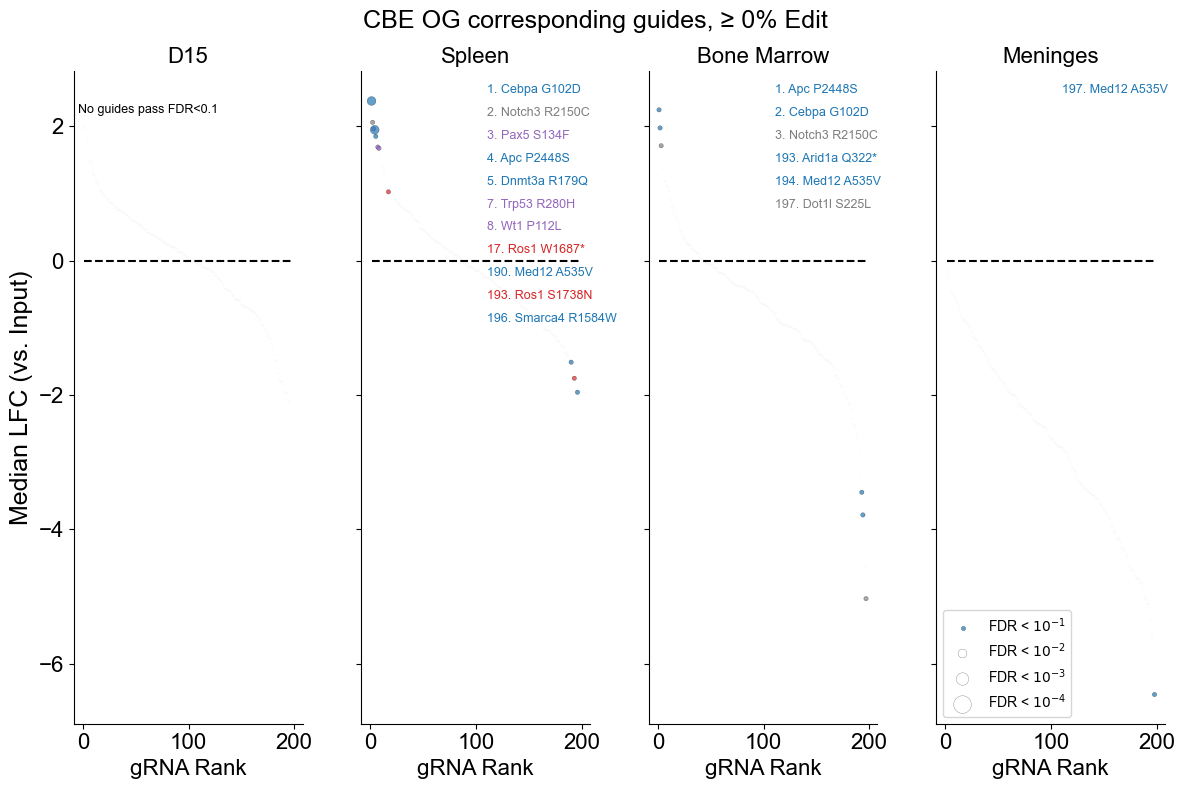

In [ ]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 10

CBE_targ = LFC_CBE_OG[(LFC_CBE_OG['classification']=='targeting guide')& (LFC_CBE_OG['target_base_edit_perc']>=min_edit) & (LFC_CBE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_og)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(LFC_CBE['gRNA_id'])].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )
#ax.set_ylim(0,20)
plt.suptitle('CBE OG corresponding guides, ≥ 0% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_og_0.pdf', dpi=300)

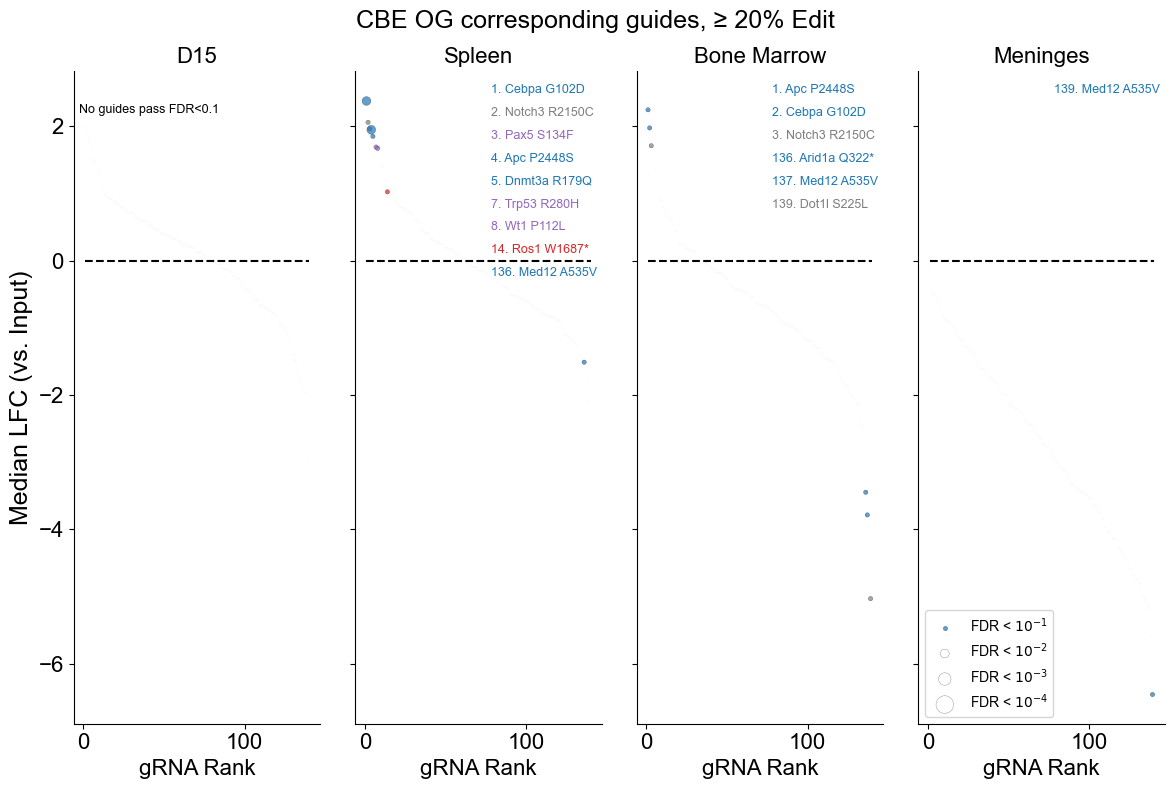

In [28]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 10

CBE_targ = LFC_CBE_OG[(LFC_CBE_OG['classification']=='targeting guide')& (LFC_CBE_OG['target_base_edit_perc']>=min_edit) & (LFC_CBE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_og)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(LFC_CBE['gRNA_id'])].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]

    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )
#ax.set_ylim(0,20)
plt.suptitle('CBE OG corresponding guides, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_og_20_NGG.pdf', dpi=300)

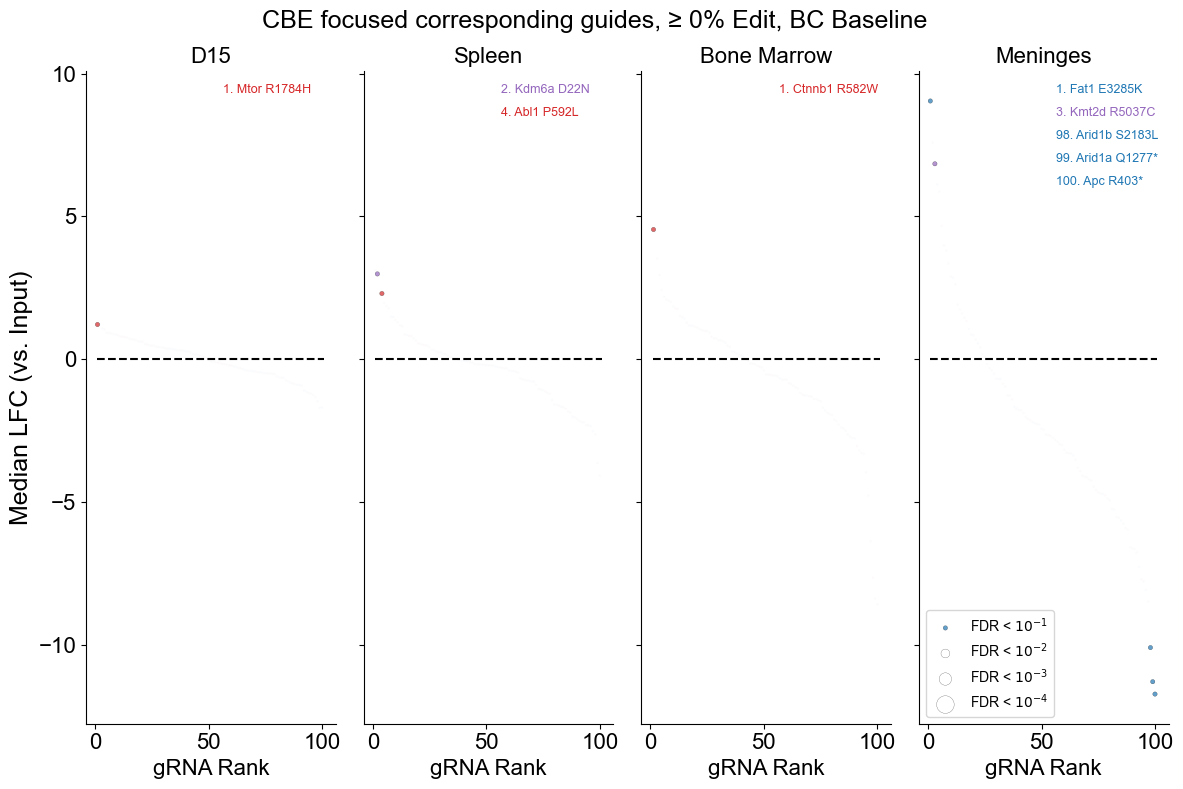

In [35]:
min_edit = 0
FDR_cutoff = .1
min_input_counts = 100

CBE_targ = LFC_CBE_VS_BC[(LFC_CBE_VS_BC['classification'].isin(['targeting guide','essential truncation guide']))&  (LFC_ABE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_ABE_VS_BC['Input_median']>=min_input_counts)]
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(LFC_CBE['gRNA_id'])].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]


    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )

#ax.set_ylim(0,20)
plt.suptitle('CBE focused corresponding guides, ≥ 0% Edit, BC Baseline',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_bc_0_NGG.pdf', dpi=300)

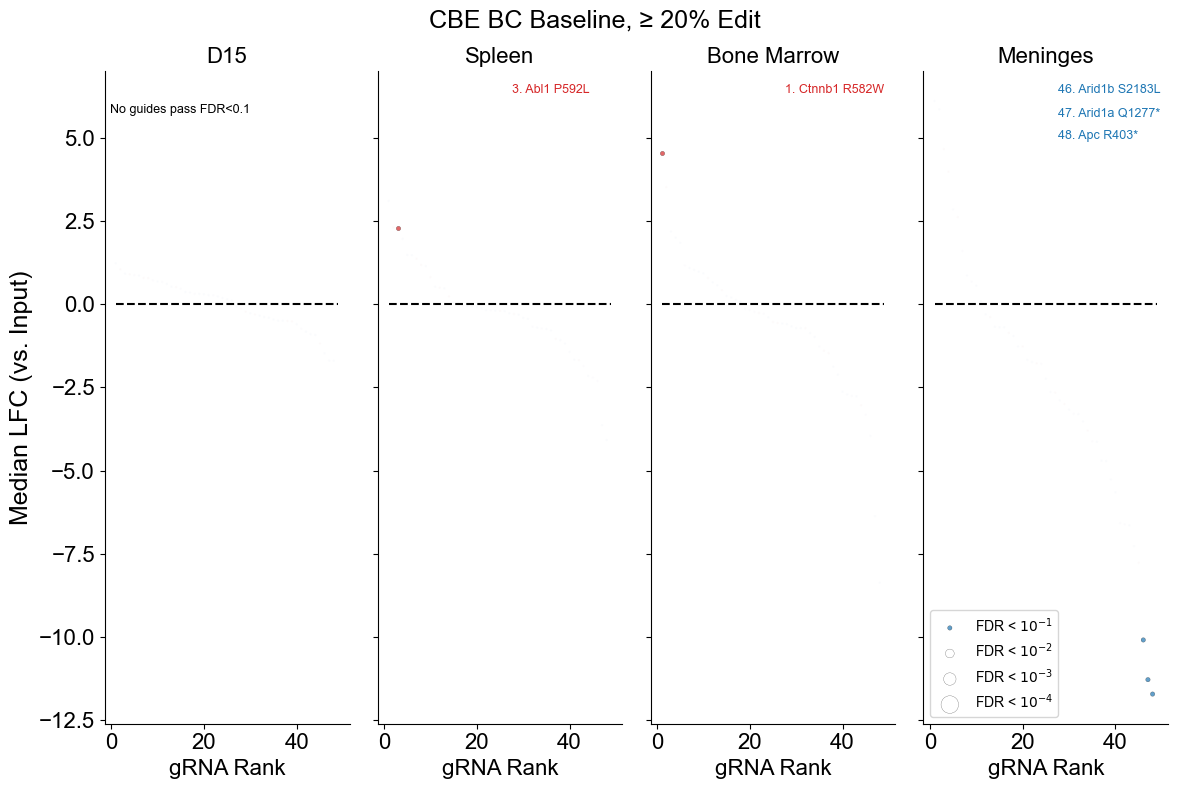

In [40]:
min_edit = 20
FDR_cutoff = .1
min_input_counts = 100

CBE_targ = LFC_CBE_VS_BC[(LFC_CBE_VS_BC['classification'].isin(['targeting guide','essential truncation guide']))&  (LFC_ABE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_ABE_VS_BC['Input_median']>=min_input_counts)]
CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)

#-----and plotting--------
names2 = ['d15','spleen', 'bm', 'men',]
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]


    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==3:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
    if len(cc3) == 0:
        ax[k].text(
            0.02, 0.95, "No guides pass FDR<0.1",
            transform=ax[k].transAxes,
            ha="left", va="top",
            fontsize=9, color="black"
        )
    else:
        top_n = min(15, len(cc3))
        bottom_n = min(5, max(0, len(cc3) - top_n))

        top = cc3.iloc[:top_n]
        bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

        tb = pd.concat((top, bottom))

        ns = []
        c = []
        for _, val2 in tb.iterrows():
            a = val2['HGVSp_m']
            if a == 'Not calculated (legacy)':
                a = val2['HGVSp_h'] + ' (human)'
            b = val2['gene_name_m_corrected']
            ns.append(f'{val2["Rank"]}. {b} {a}')
            c.append(val2['color'])

        x_left = 0.02
        x_right = 0.55
        y_top_start = 0.98
        line_h = 0.035

        # Draw top list (whatever is available)
        for i in range(top_n):
            ax[k].text(
                x_right, y_top_start - i * line_h,
                ns[i],
                transform=ax[k].transAxes,
                ha='left', va='top',
                fontsize=9,
                color=c[i],
                clip_on=False
            )

        # Draw bottom list (if any)
        for j in range(bottom_n):
            idx = top_n + j
            ax[k].text(
                x_left, 0.02 + j * line_h,
                ns[idx],
                transform=ax[k].transAxes,
                ha='left', va='bottom',
                fontsize=9,
                color=c[idx],
                clip_on=False
            )

#ax.set_ylim(0,20)
plt.suptitle('CBE BC Baseline, ≥ 20% Edit',fontsize = 18)
ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)
plt.tight_layout()
plt.savefig('figures/waterfall_cbe_bc_20_NGG.pdf', dpi=300)

## Three genes

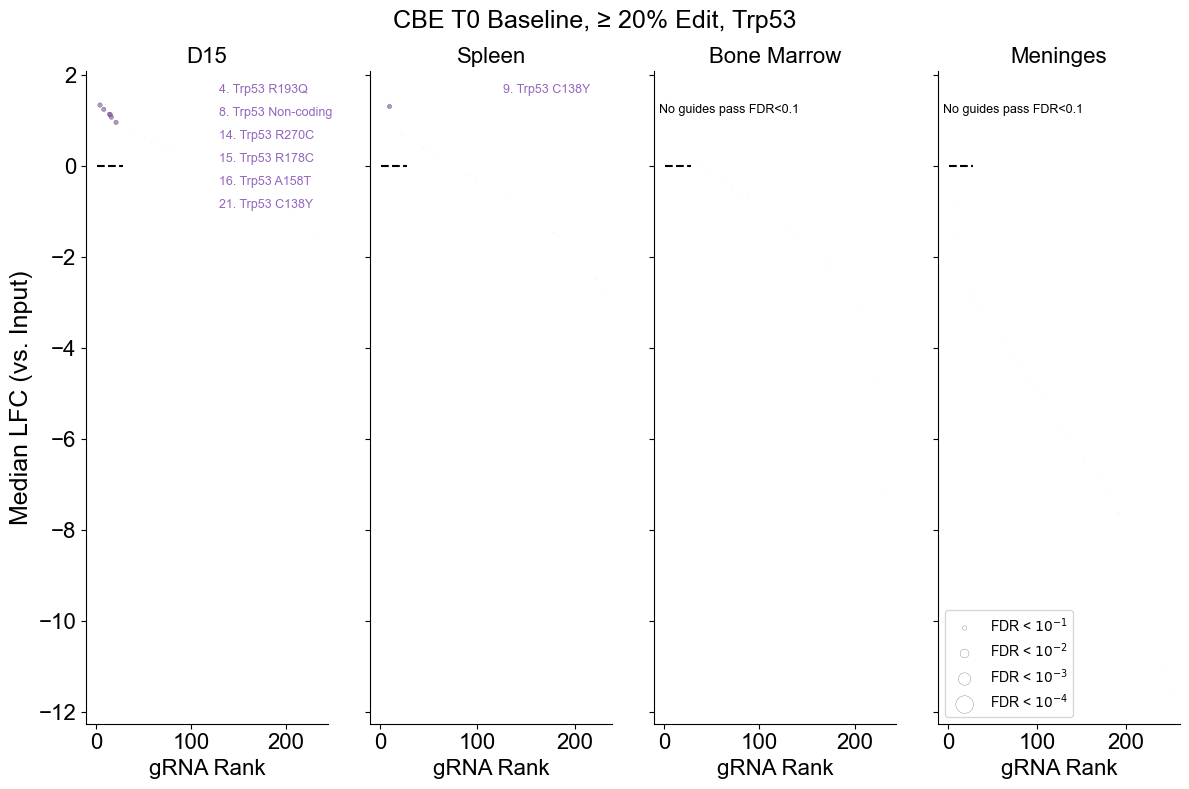

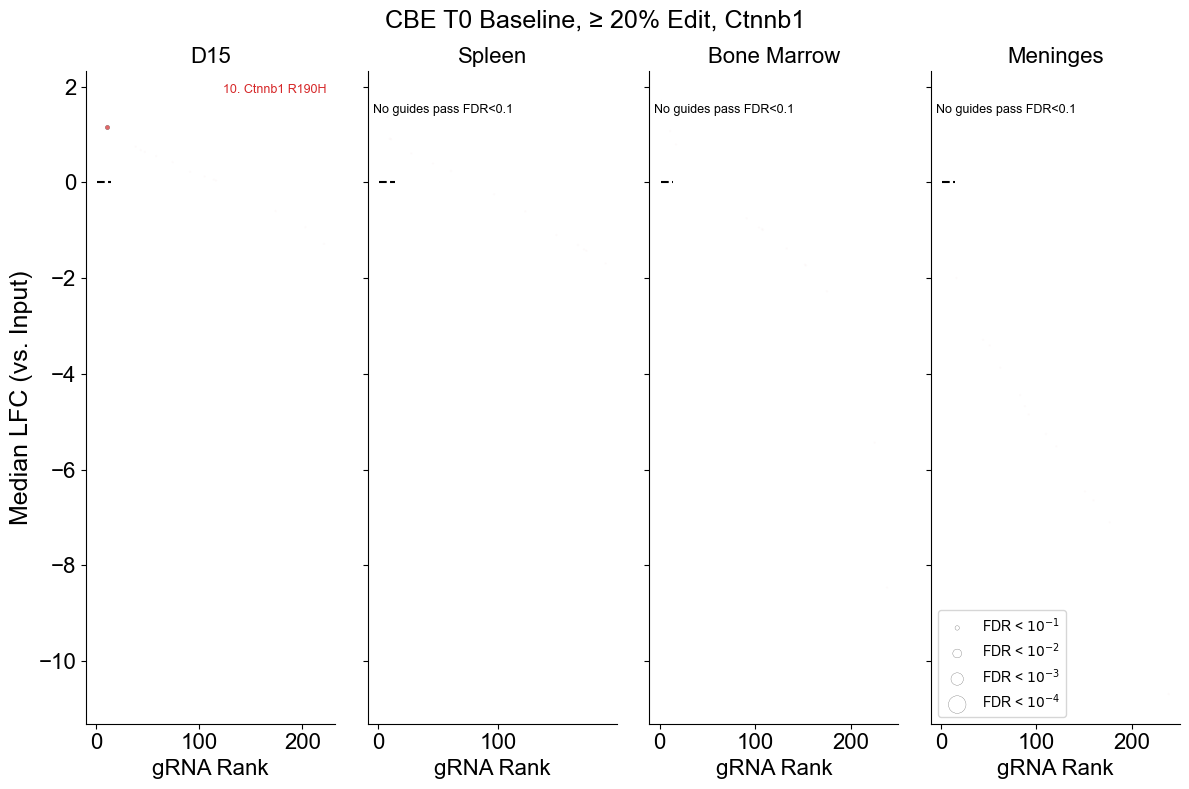

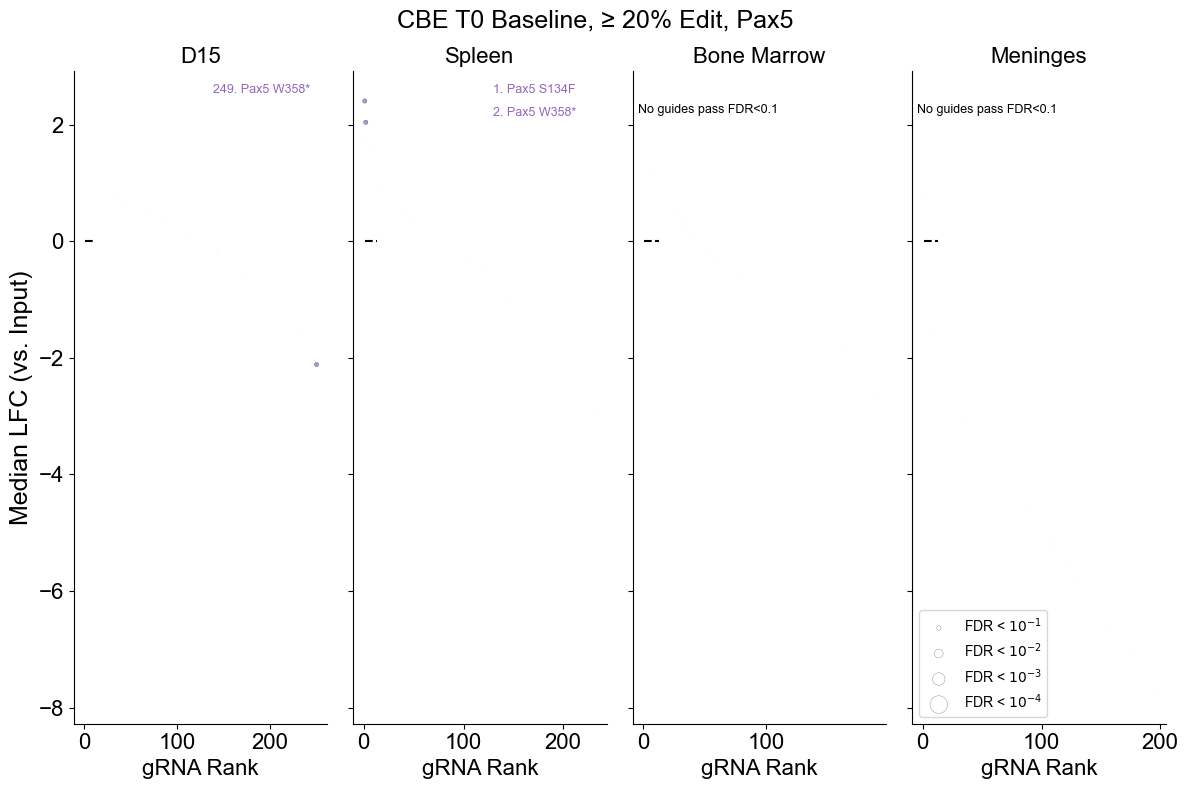

In [ ]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:

    min_edit = 0
    FDR_cutoff = .1
    min_input_counts = 100

    CBE_targ = LFC_CBE[(LFC_CBE['classification'].isin(['targeting guide','essential truncation guide']))&  (LFC_CBE['target_base_edit_perc']>=min_edit) & (LFC_CBE['Input_median']>=min_input_counts)]
    CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)
    #-----and plotting--------
    names2 = ['d15','spleen', 'bm', 'men',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)
        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)
        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

            #and annotate top and bottom 5 variant
        cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
        if len(cc3) == 0:
            ax[k].text(
                0.02, 0.95, "No guides pass FDR<0.1",
                transform=ax[k].transAxes,
                ha="left", va="top",
                fontsize=9, color="black"
            )
        else:
            top_n = min(15, len(cc3))
            bottom_n = min(5, max(0, len(cc3) - top_n))

            top = cc3.iloc[:top_n]
            bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

            tb = pd.concat((top, bottom))

            ns = []
            c = []
            for _, val2 in tb.iterrows():
                a = val2['HGVSp_m']
                if a == 'Not calculated (legacy)':
                    a = val2['HGVSp_h'] + ' (human)'
                b = val2['gene_name_m_corrected']
                ns.append(f'{val2["Rank"]}. {b} {a}')
                c.append(val2['color'])

            x_left = 0.02
            x_right = 0.55
            y_top_start = 0.98
            line_h = 0.035

            # Draw top list (whatever is available)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

            # Draw bottom list (if any)
            for j in range(bottom_n):
                idx = top_n + j
                ax[k].text(
                    x_left, 0.02 + j * line_h,
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],
                    clip_on=False
                )

    #ax.set_ylim(0,20)
    plt.suptitle(f'CBE T0 Baseline, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_cbe_focused_t0_20_{gene_of_interest}.pdf', dpi=300)
    plt.show()

In [51]:
LFC_CBE_VS_BC

,gRNA_id,Gene,bm1,bm2,bm3,bm4,bm5,LFC_avg_bm,LFC_median_bm,Input_median,...,p_low_unadjusted_men_fishers,FDR_high_men_fishers,FDR_low_men_fishers,p_high_unadjusted_men_stouffers,p_low_unadjusted_men_stouffers,FDR_high_men_stouffers,FDR_low_men_stouffers,FDR_men_fishers,FDR_men_stouffers,Role in Cancer
0,gRNA_4,Abl1,-1.487169,-2.170318,0.421527,0.826223,-11.688506,-2.819649,-1.487169,1562.391429,...,0.253318,0.999998,0.883873,0.810956,0.189271,1.000000,0.699550,0.883873,0.699550,Oncogene
1,gRNA_19,Abl1,3.525493,0.794397,4.329306,2.897481,4.190530,3.147442,3.525493,433.725947,...,0.406119,0.999998,0.999994,0.689446,0.310832,1.000000,0.851232,0.999994,0.851232,Oncogene
2,gRNA_21,Abl1,3.017150,-1.317090,-5.475350,-0.522993,-1.635250,-1.186707,-1.317090,480.620157,...,0.899816,0.956068,0.999994,0.138959,0.862713,0.695902,1.000000,0.956068,0.695902,Oncogene
3,gRNA_289,Apc,-6.369467,-5.016766,-8.671747,1.542628,-10.405294,-5.784129,-6.369467,867.063139,...,0.000096,0.999998,0.013393,0.999983,0.000017,1.000000,0.003661,0.013393,0.003661,TSG
4,gRNA_295,Apc,-7.816926,-8.588553,-6.060313,-8.639337,-1.799506,-6.580927,-7.816926,102.098182,...,0.401908,0.999998,0.999994,0.728860,0.271369,1.000000,0.801373,0.999994,0.801373,TSG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,gRNA_15007,controlsgRNA,-6.353957,0.593804,-8.182306,-1.176368,-11.330890,-5.289944,-6.353957,348.455550,...,0.946233,0.999998,0.999994,0.126691,0.878490,0.683395,1.000000,0.999994,0.683395,Undefined
1253,gRNA_15008,controlsgRNA,2.039083,1.880689,1.410782,3.597446,-8.730850,0.039430,1.880689,1111.143277,...,0.776604,0.881877,0.999994,0.185486,0.819828,0.761949,1.000000,0.881877,0.761949,Undefined
1254,gRNA_15009,controlsgRNA,1.976027,0.925569,-2.858679,1.879578,-4.220970,-0.459695,0.925569,1343.021151,...,0.438402,0.999998,0.999994,0.448438,0.553941,0.979772,1.000000,0.999994,0.979772,Undefined
1255,gRNA_15010,controlsgRNA,-7.094433,-8.187989,-0.430930,1.850347,-9.808332,-4.734268,-7.094433,387.810540,...,0.999373,0.077409,0.999994,0.000208,0.999805,0.039479,1.000000,0.077409,0.039479,Undefined


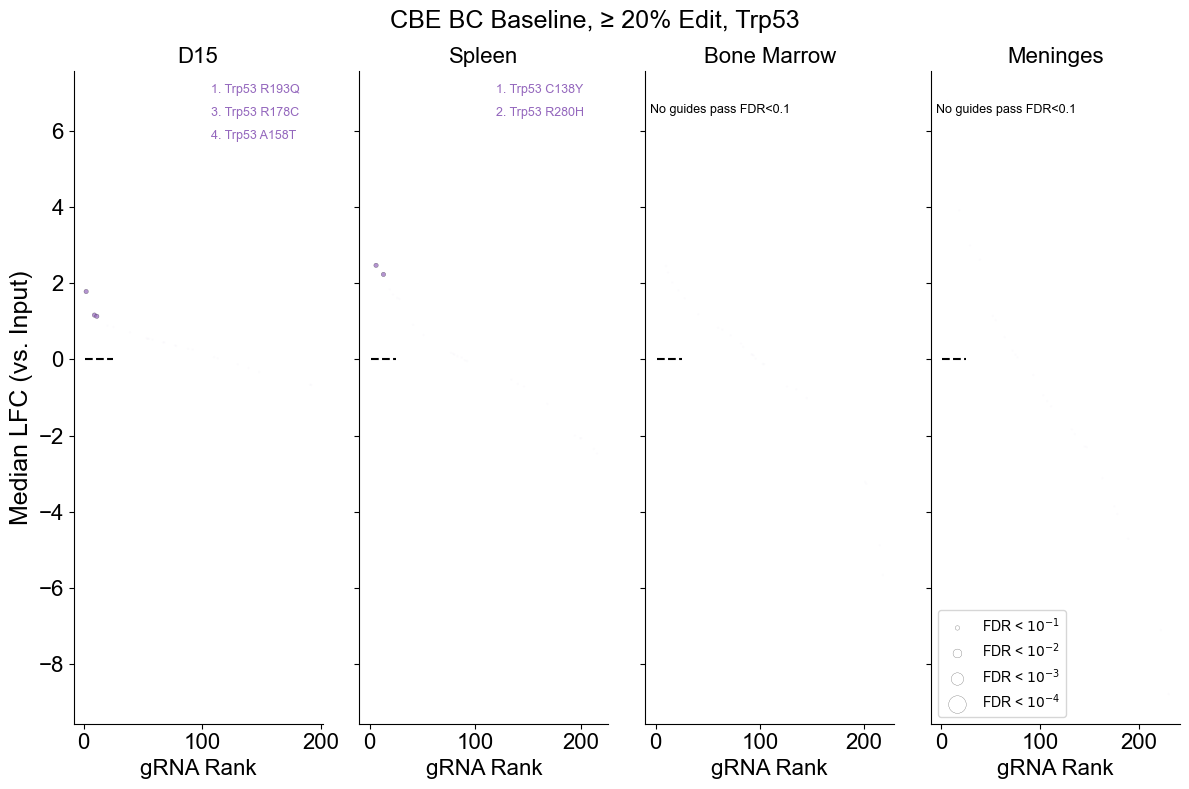

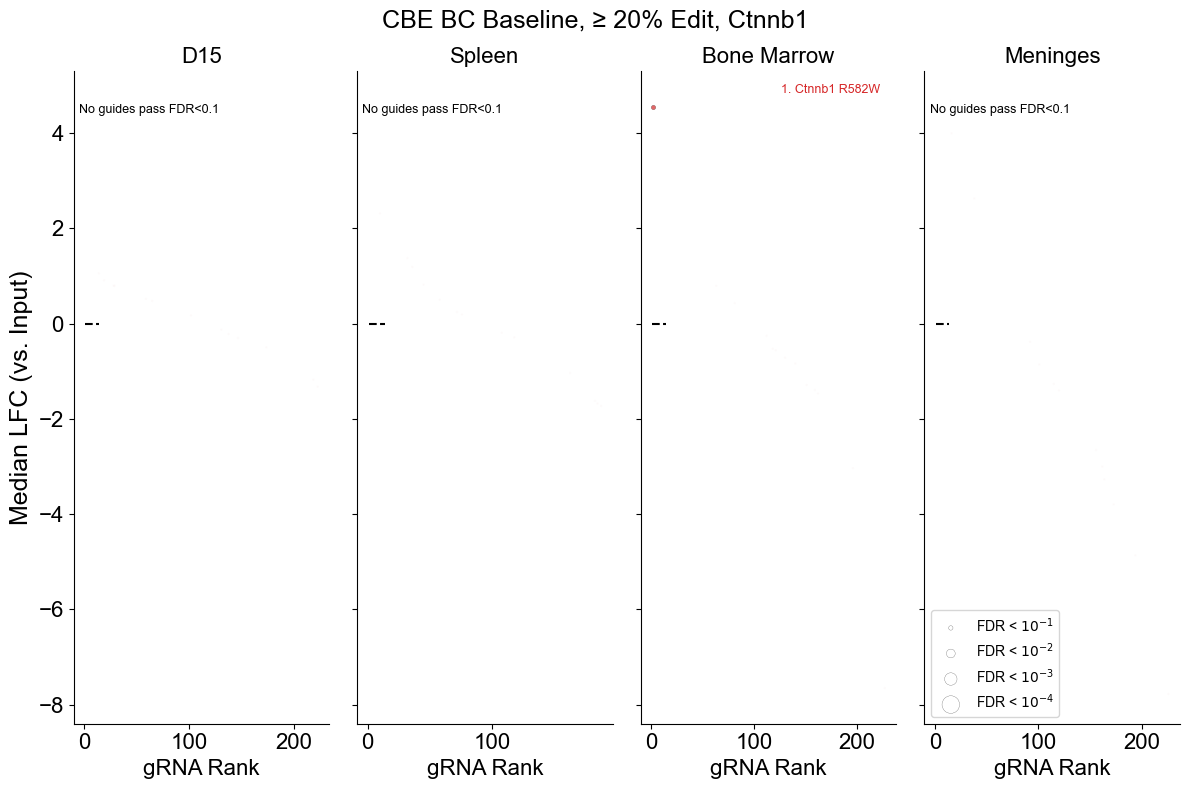

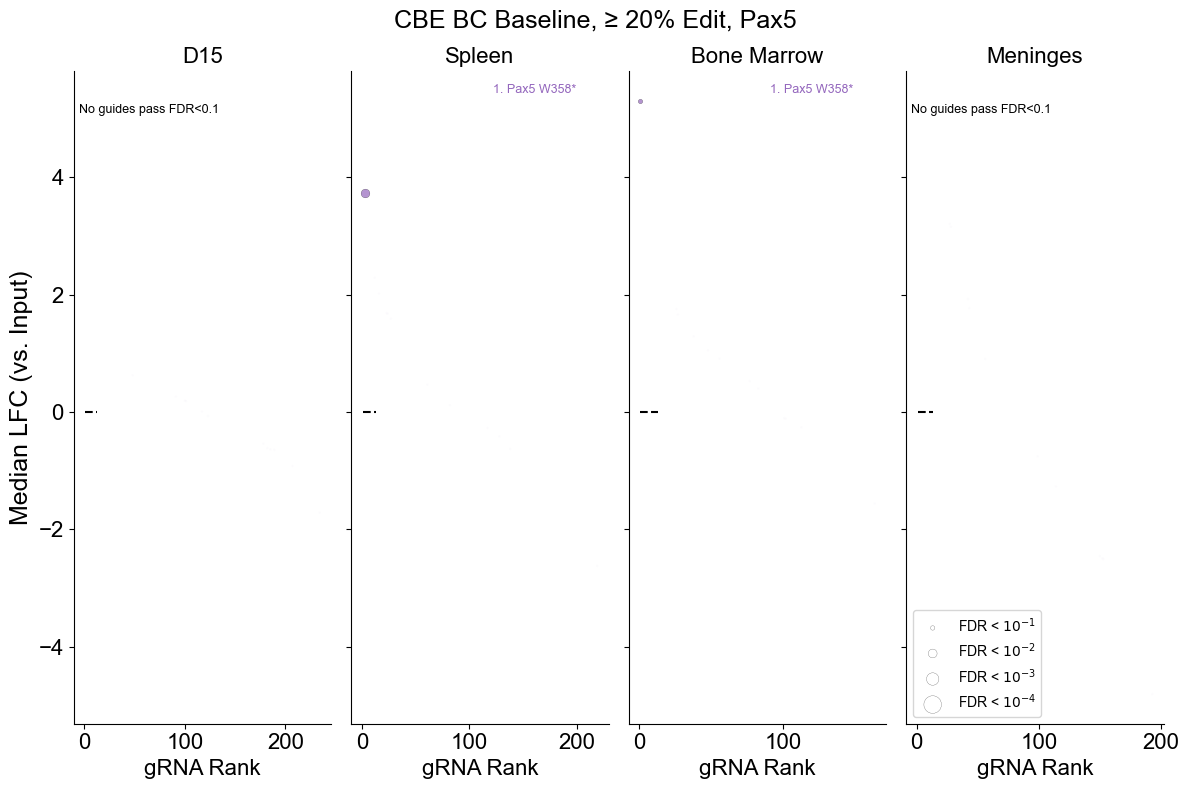

In [52]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:
    min_edit = 20
    FDR_cutoff = .1
    min_input_counts = 100

    CBE_targ = LFC_CBE_VS_BC[(LFC_CBE_VS_BC['classification'].isin(['targeting guide','essential truncation guide']))&  (LFC_CBE_VS_BC['target_base_edit_perc_epo']>=min_edit) & (LFC_CBE_VS_BC['Input_median']>=min_input_counts)]
    CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_focused)].reset_index(drop=True)

    #-----and plotting--------
    names2 = ['d15','spleen', 'bm', 'men',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)

        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

        cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()

        # If nothing significant, optionally show a small note and skip
        if len(cc3) == 0:
            ax[k].text(
                0.02, 0.95, "No guides pass FDR<0.1",
                transform=ax[k].transAxes,
                ha="left", va="top",
                fontsize=9, color="black"
            )
        else:
            top_n = min(15, len(cc3))
            bottom_n = min(5, max(0, len(cc3) - top_n))

            top = cc3.iloc[:top_n]
            bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

            tb = pd.concat((top, bottom))

            ns = []
            c = []
            for _, val2 in tb.iterrows():
                a = val2['HGVSp_m']
                if a == 'Not calculated (legacy)':
                    a = val2['HGVSp_h'] + ' (human)'
                b = val2['gene_name_m_corrected']
                ns.append(f'{val2["Rank_gene"]}. {b} {a}')
                c.append(val2['color'])

            x_left = 0.02
            x_right = 0.55
            y_top_start = 0.98
            line_h = 0.035

            # Draw top list (whatever is available)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

            # Draw bottom list (if any)
            for j in range(bottom_n):
                idx = top_n + j
                ax[k].text(
                    x_left, 0.02 + j * line_h,
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],
                    clip_on=False
                )

    #ax.set_ylim(0,20)
    plt.suptitle(f'CBE BC Baseline, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_cbe_focused_bc_20_{gene_of_interest}.pdf', dpi=300)
    plt.show()

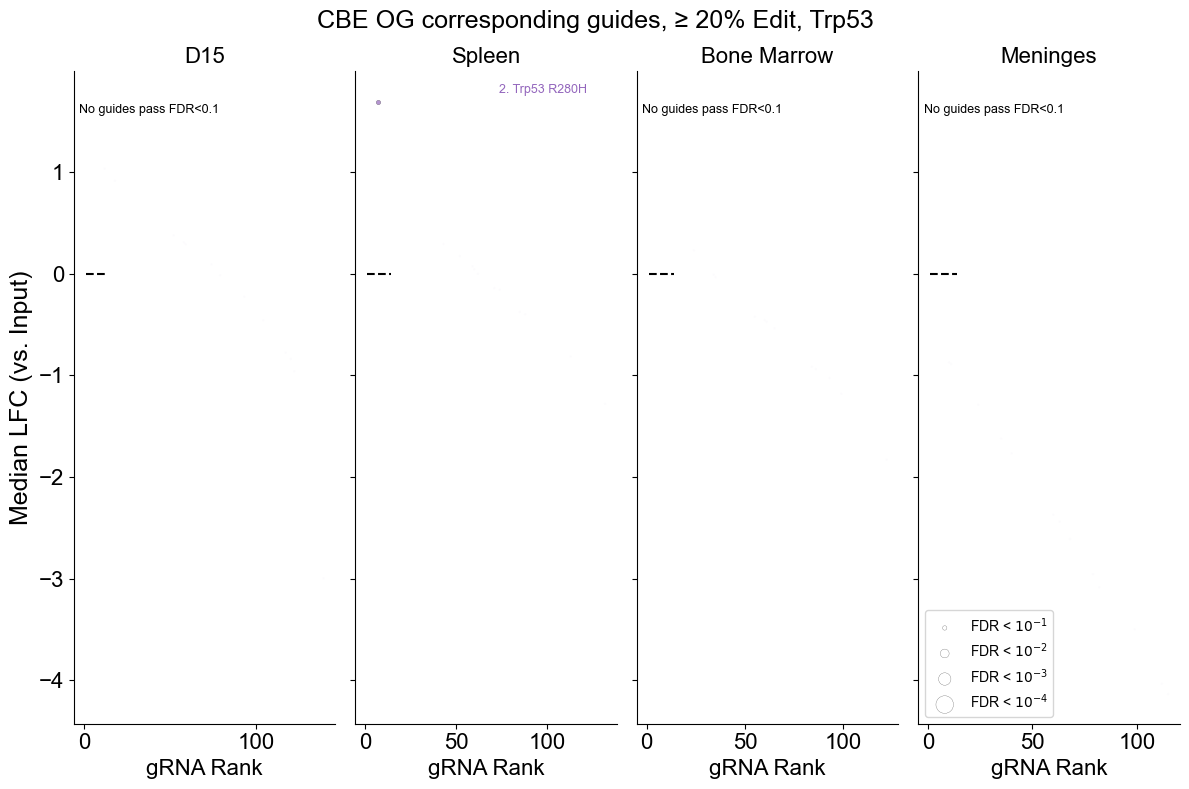

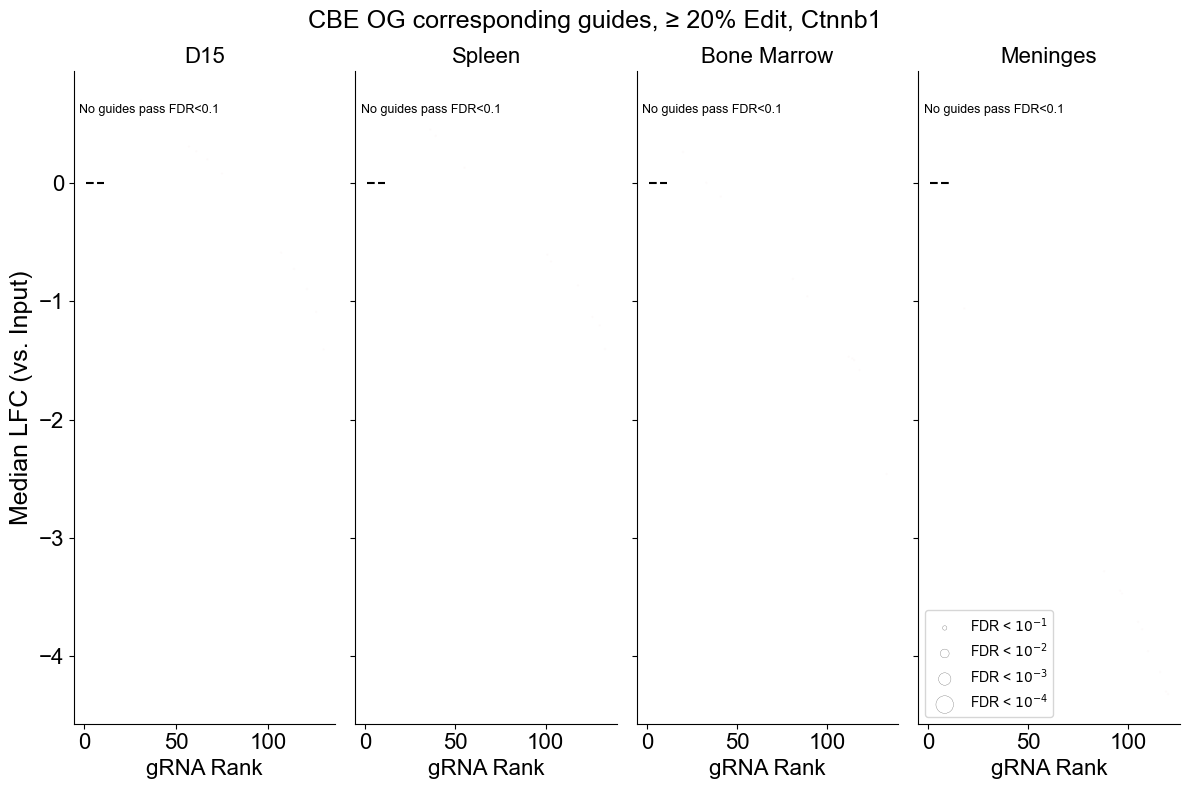

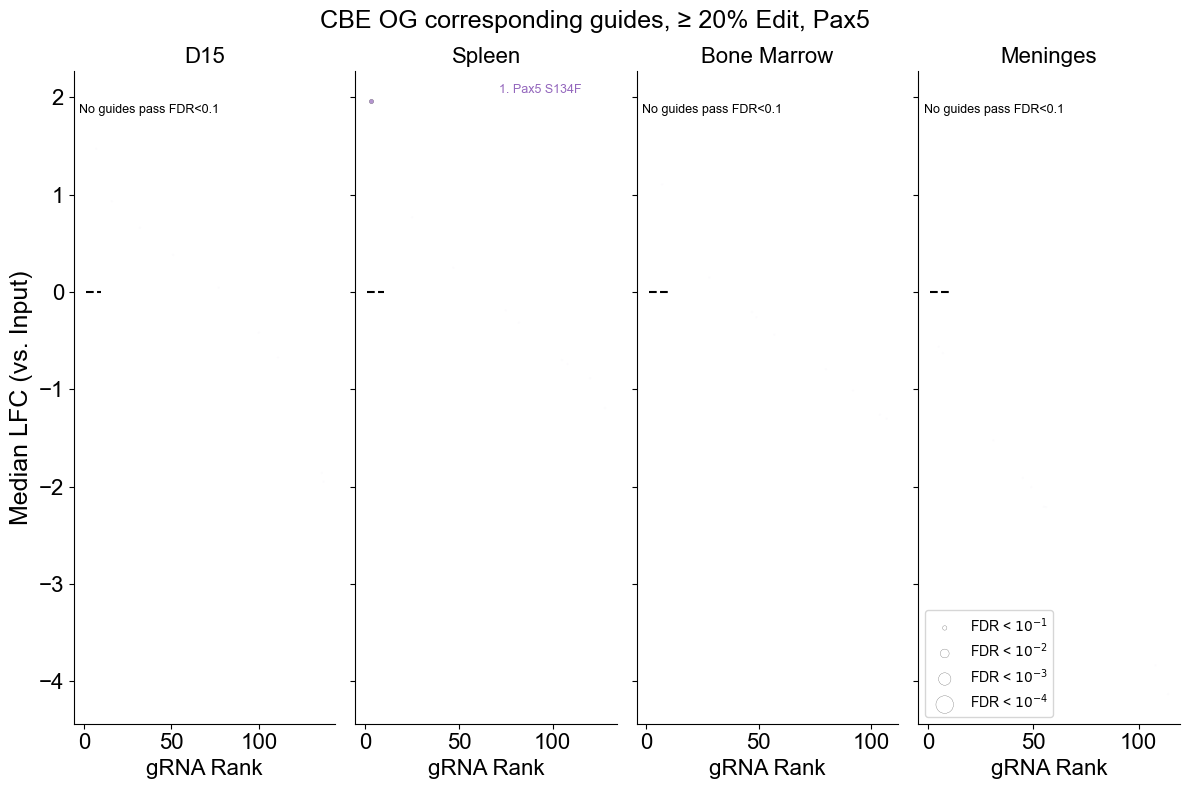

In [55]:
for gene_of_interest in ['Trp53', 'Ctnnb1','Pax5']:
    min_edit = 20
    FDR_cutoff = .1
    min_input_counts = 10

    CBE_targ = LFC_CBE_OG[(LFC_CBE_OG['classification']=='targeting guide')& (LFC_CBE_OG['target_base_edit_perc']>=min_edit) & (LFC_CBE_OG['Input_median']>=min_input_counts)].reset_index(drop=True)
    CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(guides_NGG_CBE_og)].reset_index(drop=True)
    CBE_targ = CBE_targ[CBE_targ['gRNA_id'].isin(LFC_CBE['gRNA_id'])].reset_index(drop=True)

    #-----and plotting--------
    names2 = ['d15','spleen', 'bonemarrow', 'meninges',]
    color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

    fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

    for k, val in enumerate(names2):
        #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
        #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
        #cc2 = cc2.sort_values(by='LFC', ascending=False)

        cc2 = CBE_targ.sort_values(by=f'LFC_median_{val}', ascending=False)

        cc2['Rank'] = range(1, len(cc2)+1)
        cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]
        cc2 = cc2[cc2['gene_name_m_corrected']==gene_of_interest].reset_index(drop=True)
        cc2['Rank_gene']    = range(1, len(cc2)+1)

        #split by significance level

        cc2_other = cc2[cc2[f'FDR_{val}_fishers']>=FDR_cutoff]
        ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}'], color=cc2_other['color'], s=1, alpha=.01)

        #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

        FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

        size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
        label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

    # for id1, cut in enumerate(FDR_cutoffs):
        #   if id1==0:
        #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
                
        #   else:
        #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

        #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

        for id1, cut in enumerate(FDR_cutoffs):
            if id1==3:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut)]
                
            else:
                cc2_sig = cc2[(cc2[f'FDR_{val}_fishers']<cut) &(cc2[f'FDR_{val}_fishers']>=FDR_cutoffs[id1+1])]

            ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

        if k==3:
            ax[k].legend(loc='lower left')

        #------making plot pretty------

        ax[k].spines[['top', 'right']].set_visible(False)
        ax[k].tick_params(axis='both', which='major', labelsize=16,)
        ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
        ax[k].set_xlabel('gRNA Rank', fontsize=16)

        cc3 = cc2[cc2[f'FDR_{val}_fishers'] < FDR_cutoff].copy()
       # If nothing significant, optionally show a small note and skip
        if len(cc3) == 0:
            ax[k].text(
                0.02, 0.95, "No guides pass FDR<0.1",
                transform=ax[k].transAxes,
                ha="left", va="top",
                fontsize=9, color="black"
            )
        else:
            top_n = min(15, len(cc3))
            bottom_n = min(5, max(0, len(cc3) - top_n))

            top = cc3.iloc[:top_n]
            bottom = cc3.iloc[-bottom_n:] if bottom_n > 0 else cc3.iloc[0:0]

            tb = pd.concat((top, bottom))

            ns = []
            c = []
            for _, val2 in tb.iterrows():
                a = val2['HGVSp_m']
                if a == 'Not calculated (legacy)':
                    a = val2['HGVSp_h'] + ' (human)'
                b = val2['gene_name_m_corrected']
                ns.append(f'{val2["Rank_gene"]}. {b} {a}')
                c.append(val2['color'])

            x_left = 0.02
            x_right = 0.55
            y_top_start = 0.98
            line_h = 0.035

            # Draw top list (whatever is available)
            for i in range(top_n):
                ax[k].text(
                    x_right, y_top_start - i * line_h,
                    ns[i],
                    transform=ax[k].transAxes,
                    ha='left', va='top',
                    fontsize=9,
                    color=c[i],
                    clip_on=False
                )

            # Draw bottom list (if any)
            for j in range(bottom_n):
                idx = top_n + j
                ax[k].text(
                    x_left, 0.02 + j * line_h,
                    ns[idx],
                    transform=ax[k].transAxes,
                    ha='left', va='bottom',
                    fontsize=9,
                    color=c[idx],
                    clip_on=False
                )

    #ax.set_ylim(0,20)
    plt.suptitle(f'CBE OG corresponding guides, ≥ 20% Edit, {gene_of_interest}',fontsize = 18)
    ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
    ax[0].set_title('D15', fontsize=16)
    ax[1].set_title('Spleen', fontsize=16)
    ax[2].set_title('Bone Marrow', fontsize=16)
    ax[3].set_title('Meninges', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'figures/waterfall_cbe_og_20_{gene_of_interest}_NGG.pdf', dpi=300)
    plt.show()